In [99]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import random
import plotly.express as px
import plotly.graph_objects as go


from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.cluster import KMeans, BisectingKMeans
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr

from pyclustering.cluster import xmeans

from kneed import KneeLocator
from yellowbrick.cluster import SilhouetteVisualizer

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from matplotlib import cm

We're going to use the log transformation of runtimeMinutes.

In [100]:
df = pd.read_csv("../results/train_clean.csv", index_col=0)
df['genres'] = df['genres'].apply(ast.literal_eval)
df['logRuntime'] = np.log(df['runtimeMinutes'] + 1)

df.describe()

,startYear,runtimeMinutes,numVotes,totalImages,totalCredits,numRegions,ratingNum,numGenres,criticReviewsRatio,logRuntime
count,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000
mean,1991.867081,58.480494,4.079722,1.302735,3.499824,1.161221,7.155620,1.927332,0.165655,3.817365
std,26.120690,46.475639,1.760203,1.194015,1.111965,0.707212,1.386902,0.830975,0.304980,0.820471
min,1878.000000,0.000000,1.791759,0.000000,0.000000,0.693147,1.000000,1.000000,0.000000,0.000000
25%,1978.000000,29.000000,2.772589,0.693147,2.833213,0.693147,6.000000,1.000000,0.000000,3.401197
50%,1997.000000,50.000000,3.610918,0.693147,3.555348,0.693147,7.000000,2.000000,0.000000,3.931826
75%,2013.000000,90.000000,5.007291,1.945910,4.189655,1.386294,8.000000,3.000000,0.226540,4.510860
max,2024.000000,3000.000000,13.781505,8.161946,9.664151,4.248495,10.000000,3.000000,1.000000,8.006701


In [101]:
numeric_cols = df.dtypes[(df.dtypes == 'float64') | (df.dtypes == 'int64')].index
numeric_df = df[numeric_cols]
numeric_df.drop(['ratingNum', 'runtimeMinutes'], axis=1, inplace=True) #drop ratingNum bc it is the target variable
#numeric_df.drop(['ratingNum'], axis=1, inplace=True) 
numeric_df.head()

C:\Users\camim\AppData\Local\Temp\ipykernel_27592\3860749921.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,startYear,numVotes,totalImages,totalCredits,numRegions,numGenres,criticReviewsRatio,logRuntime
0,1995,6.659294,0.693147,3.091042,0.693147,3,1.000000,3.713572
1,1982,2.484907,0.693147,0.693147,0.693147,1,0.000000,3.367296
2,1992,3.663562,0.693147,3.218876,0.693147,1,0.000000,4.510860
3,2021,2.772589,3.135494,4.043051,0.693147,1,0.000000,3.465736
4,2020,9.662625,5.852202,3.871201,3.496508,3,0.008772,4.394449


In [102]:
#scaling → MinMaxScaler yields better Silhouette Scores wrt StandardScaler and RobustScaler
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df.values)

# K-means

Determining the best K

In [103]:
%%time
sse_list = []
sil_list = []
dist = squareform(pdist(X)) #Euclidean distance

for k in range(2, 51): 
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
    kmeans.fit(X)
    sse_list.append(kmeans.inertia_) #sse
    sil_list.append(silhouette_score(dist, kmeans.labels_, metric='precomputed'))

CPU times: total: 4min 26s
Wall time: 2min 4s


In [104]:
k_values = list(range(2, 51))  
knee_locator = KneeLocator(k_values, sse_list, curve='convex', direction='decreasing')
print(f"Elbow: {knee_locator.knee}")

Elbow: 13


In [105]:
coeffs = np.array(sil_list)
top_indices = np.argsort(coeffs)[::-1][:15]
top_scores = np.sort(coeffs)[::-1][:15] 

print("Top 15 best k values for silhouette score:")
for k, score in zip(top_indices, top_scores):
    print(f"k = {k+2}, score = {score}") #adjust k value to start from 2

Top 15 best k values for silhouette score:
k = 2, score = 0.25864130315595835
k = 5, score = 0.1933750535949572
k = 6, score = 0.19209632339538496
k = 7, score = 0.18896691844962316
k = 4, score = 0.18682564476966546
k = 8, score = 0.18171489353627804
k = 9, score = 0.17028666509290724
k = 3, score = 0.1696244539208962
k = 14, score = 0.16749605866397524
k = 13, score = 0.16721132367498082
k = 12, score = 0.16560553804072656
k = 10, score = 0.16307909912249258
k = 11, score = 0.16233702469010666
k = 15, score = 0.15873097626806867
k = 16, score = 0.1582197658725618


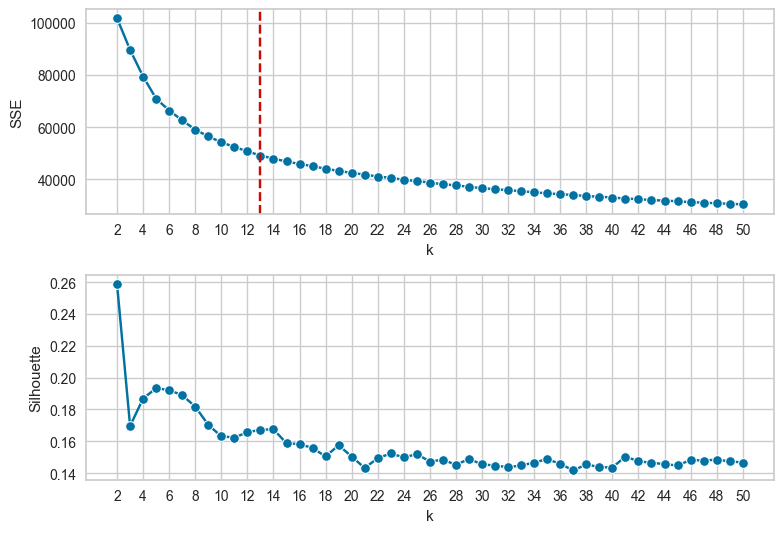

In [106]:
fig, axs = plt.subplots(2) 

sns.lineplot(x=k_values, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')
axs[0].axvline(knee_locator.knee, color='r', linestyle='--')
axs[0].set_xticks(np.arange(2,51,2))

sns.lineplot(x=k_values, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette')
axs[1].set_xticks(np.arange(2,51,2))

plt.tight_layout()

## k = 8
We choose 8 as a trade off between SSE and Silhouette Score.

In [107]:
k = 8

In [108]:
kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=0)
kmeans.fit(X)

KMeans(max_iter=100, n_init=10, random_state=0)

In [109]:
labels, counts = np.unique(kmeans.labels_, return_counts=True)
print("Cluster sizes:")
for label, count in zip(labels,counts):
    print(f"Cluster {label}:\t{count}")

print('\nSSE:', kmeans.inertia_)
print('Silhouette score:', silhouette_score(X, kmeans.labels_))

Cluster sizes:
Cluster 0:	1726
Cluster 1:	3064
Cluster 2:	1709
Cluster 3:	1742
Cluster 4:	1339
Cluster 5:	1764
Cluster 6:	863
Cluster 7:	4224

SSE: 58994.37056058087
Silhouette score: 0.1816944192145104


In [110]:
def compute_correlation(X, labels, dist = None):
    if dist is None:
        dist = squareform(pdist(X))

    # Compute the ideal similarity matrix
    shape = len(X)
    ideal_sim = np.eye(shape)

    for i in range(shape):
        for j in range(0, i + 1):
            ideal_sim[j][i] = 1 if labels[i] == labels[j] else 0

    # Make the matrix symmetric
    ideal_sim = ideal_sim + ideal_sim.T - np.diag(np.diag(ideal_sim))

    # Compute the correlation
    correlation, _ = pearsonr(dist[np.triu_indices(shape, k=1)],
                                ideal_sim[np.triu_indices(shape, k=1)])
    
    return correlation

In [111]:
corr = compute_correlation(X, kmeans.labels_, dist)
print(f"Correlation between the distance matrix and the ideal similarity matrix: {corr}")

Correlation between the distance matrix and the ideal similarity matrix: -0.4368951212346562


C:\Users\camim\AppData\Local\Temp\ipykernel_27592\3560659375.py:3: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



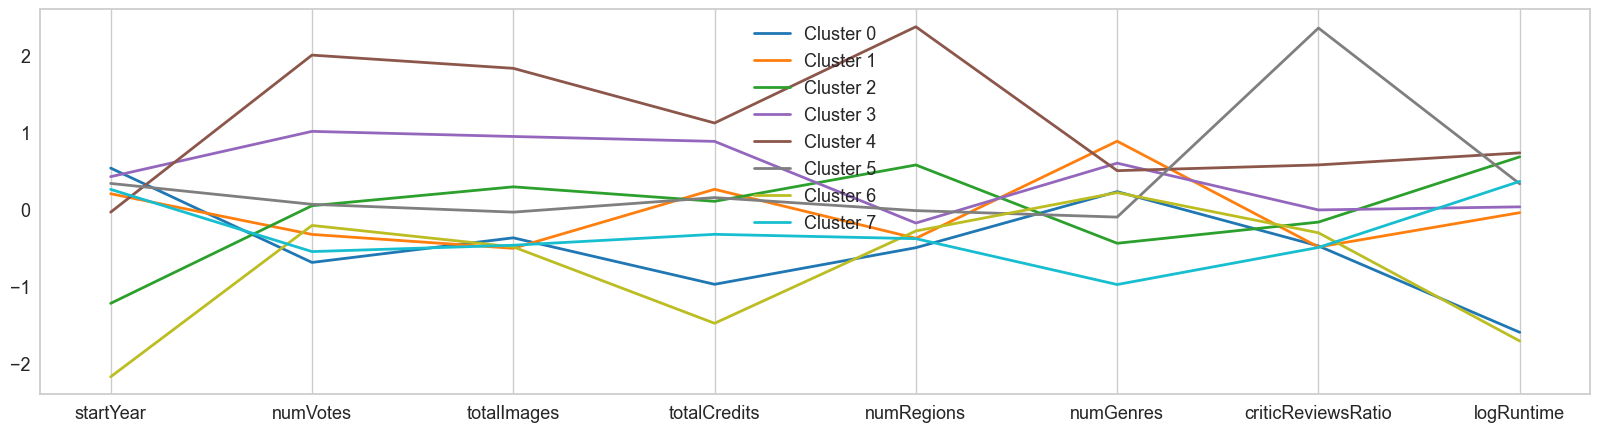

In [112]:
plt.figure(figsize=(20, 5))
centers = kmeans.cluster_centers_
colors = cm.get_cmap('tab10', len(centers)) 

for i in range(len(centers)):
    plt.plot(range(0, len(numeric_df.columns)), centers[i], label=f'Cluster {i}', linewidth=2, color=colors(i))
    
plt.xticks(range(0, len(numeric_df.columns)), numeric_df.columns, fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13, loc='best')
plt.grid(axis='y')

plt.show()

Clusters separate points mostly based on `numGenres` and `criticReviesRatio`. Quite separated based on `numVotes`, `totalImages`, `totalCredits`. 
Cluster 7 is particularly separated from the others based on `startYear` and, less dramaticallyy, based on `logRuntime`.


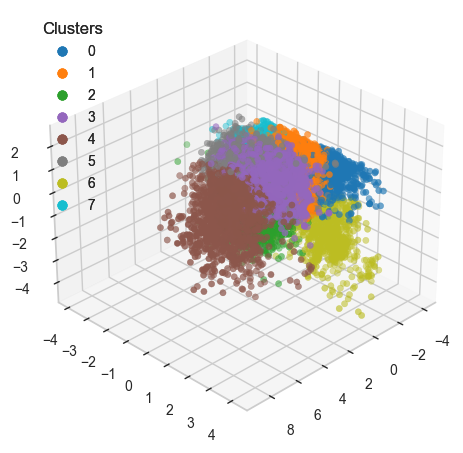

In [113]:
pca = PCA(n_components=3) 
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2', 'PC3'])
pca_data['cluster'] = pd.Categorical(kmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    pca_data['PC1'], 
    pca_data['PC2'], 
    pca_data['PC3'], 
    c=pca_data['cluster'].cat.codes, 
    cmap='tab10'
)
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=30., azim=45)

plt.show()

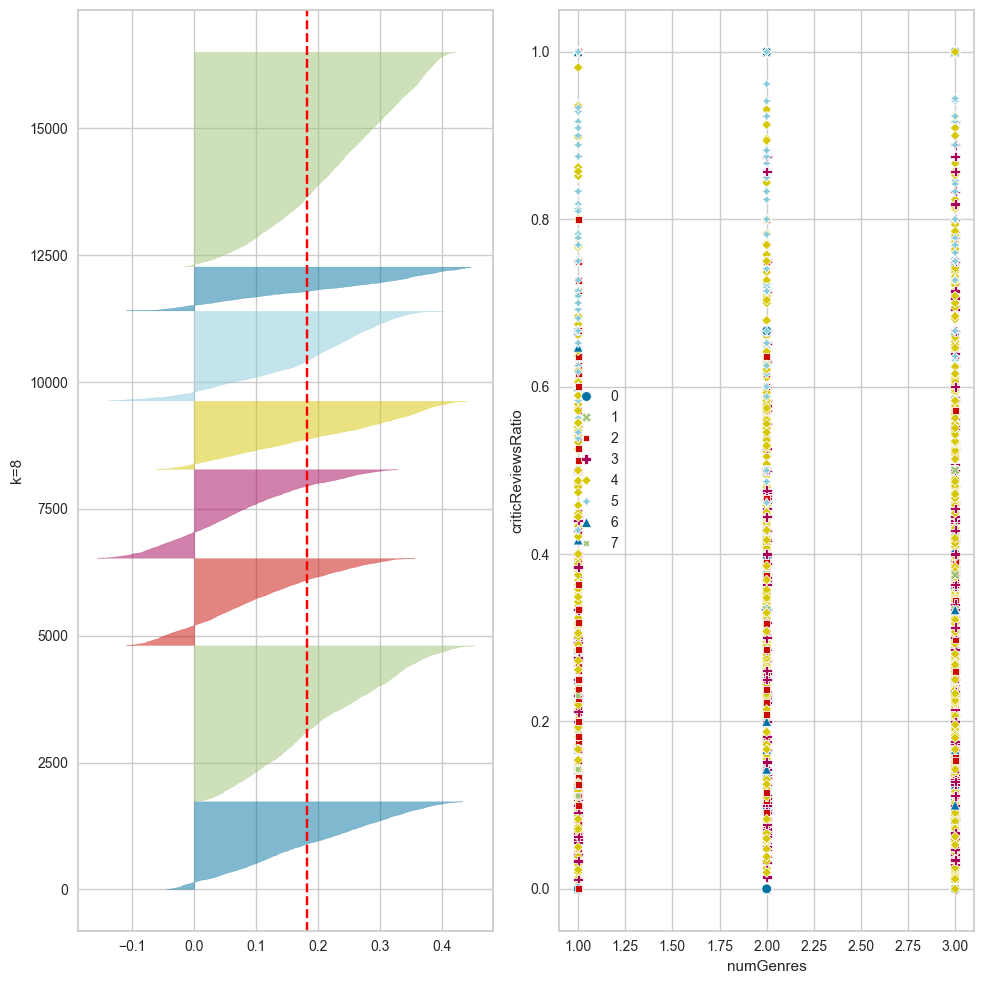

In [114]:
colors=['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
fig, axs = plt.subplots(1, 2, figsize=(10, 10))  # Adjust the size of axs array
visualizer = SilhouetteVisualizer(kmeans, colors=colors, ax=axs[0])
axs[0].set_ylabel("k=" + str(k))
visualizer.fit(X)
sns.scatterplot(data=df, x="numGenres", y="criticReviewsRatio", hue=kmeans.labels_, #numGenres and criticReviewsRatio: features that separate centroids the most
                palette=sns.color_palette(colors), style=kmeans.labels_, ax=axs[1])
plt.tight_layout()
plt.show()

## K means with selected features

Using all numerical features does not yield great results. Based on our insights from the data understanding phase, we disregard `totalImages`, `numRegions` and `totalCredits` bc they are moderately correlated w/ `numVotes`, to see if using less features provides a more meaningful clustering.

In [115]:
selected_numeric_df = numeric_df.copy()
selected_numeric_df.drop(['totalImages', 'numRegions', 'totalCredits'], axis=1, inplace=True)
selected_numeric_df.head()

,startYear,numVotes,numGenres,criticReviewsRatio,logRuntime
0,1995,6.659294,3,1.000000,3.713572
1,1982,2.484907,1,0.000000,3.367296
2,1992,3.663562,1,0.000000,4.510860
3,2021,2.772589,1,0.000000,3.465736
4,2020,9.662625,3,0.008772,4.394449


In [116]:
scaler = StandardScaler()
X = scaler.fit_transform(selected_numeric_df.values)

In [117]:
%%time
sse_list = []
sil_list = []
dist = squareform(pdist(X))

for k in range(2, 51): 
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=0)
    kmeans.fit(X)
    sse_list.append(kmeans.inertia_) #sse
    sil_list.append(silhouette_score(dist, kmeans.labels_, metric='precomputed'))

CPU times: total: 3min 34s
Wall time: 1min 51s


In [118]:
k_values = list(range(2, 51))  
knee_locator = KneeLocator(k_values, sse_list, curve='convex', direction='decreasing')
print(f"Elbow: {knee_locator.knee}")

Elbow: 12


In [119]:
coeffs = np.array(sil_list)
top_indices = np.argsort(coeffs)[::-1][:15]
top_scores = np.sort(coeffs)[::-1][:15] 

print("Top 15 best k values for silhouette score:")
for k, score in zip(top_indices, top_scores):
    print(f"k = {k+2}, score = {score}") #adjust k value to start from 2

Top 15 best k values for silhouette score:
k = 2, score = 0.2753300311946213
k = 5, score = 0.2587369924643896
k = 43, score = 0.25745085178144383
k = 6, score = 0.25416777126199924
k = 4, score = 0.25336087132835705
k = 37, score = 0.25321923795006024
k = 45, score = 0.2528404329855711
k = 49, score = 0.2516709652452062
k = 48, score = 0.25144235892626937
k = 42, score = 0.25072709718098996
k = 50, score = 0.2505573401061066
k = 47, score = 0.25000359149106777
k = 44, score = 0.2492625240909783
k = 8, score = 0.24907005782276437
k = 7, score = 0.24874339364867182


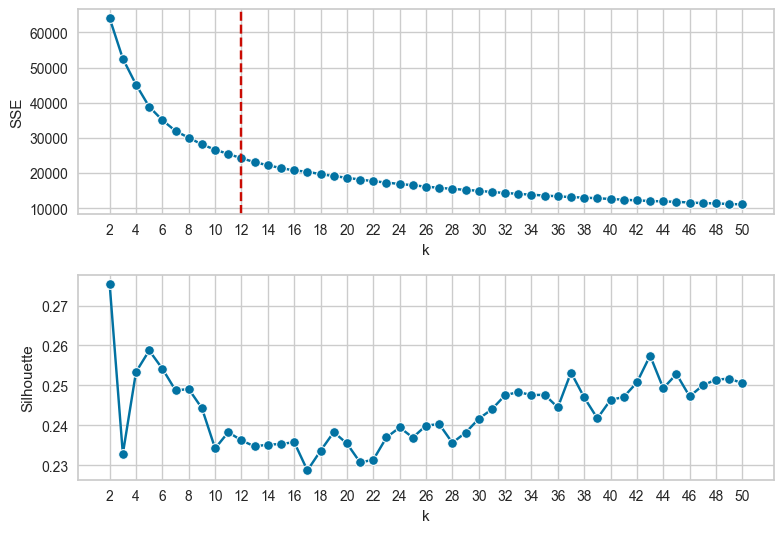

In [120]:
fig, axs = plt.subplots(2) 

sns.lineplot(x=k_values, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')
axs[0].axvline(knee_locator.knee, color='r', linestyle='--')
axs[0].set_xticks(np.arange(2,51,2))

sns.lineplot(x=k_values, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette')
axs[1].set_xticks(np.arange(2,51,2))

plt.tight_layout()

We select k = 8. We do get a better SSE and Silhouette Score.

In [121]:
k = 8

In [122]:
kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
kmeans.fit(X)

KMeans(max_iter=100, n_init=10, random_state=42)

In [123]:
labels, counts = np.unique(kmeans.labels_, return_counts=True)
print("Cluster sizes:")
for label, count in zip(labels,counts):
    print(f"Cluster {label}:\t{count}")

print('\nSSE:', kmeans.inertia_)
print('Silhouette score:', silhouette_score(X, kmeans.labels_))

Cluster sizes:
Cluster 0:	1943
Cluster 1:	4468
Cluster 2:	1768
Cluster 3:	1360
Cluster 4:	2828
Cluster 5:	2376
Cluster 6:	759
Cluster 7:	929

SSE: 30001.022643684704
Silhouette score: 0.24922022544214892


In [124]:
corr = compute_correlation(X, kmeans.labels_, dist)
print(f"Correlation between the distance matrix and the ideal similarity matrix: {corr}")

Correlation between the distance matrix and the ideal similarity matrix: -0.5086385639131191


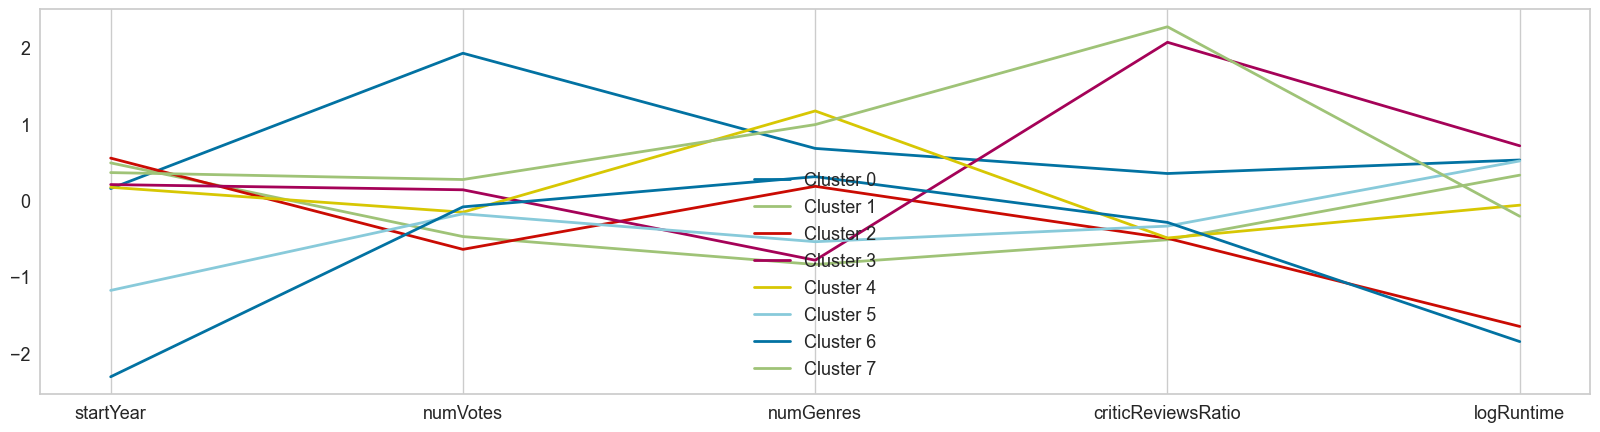

In [125]:
plt.figure(figsize=(20, 5))
centers = kmeans.cluster_centers_
for i in range(len(centers)):
    plt.plot(range(0, len(selected_numeric_df.columns)), centers[i], label='Cluster %s' % i, linewidth=2)
    
plt.xticks(range(0, len(selected_numeric_df.columns)), selected_numeric_df.columns, fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13, loc='best')
plt.grid(axis='y')

plt.show()

Again, clusters separate points mostly based on `numGenres` and `criticReviesRatio`. Quite separated based on `numVotes`, and `logRuntime`. Cluster 2 is particularly separated from the others based on `startYear`.


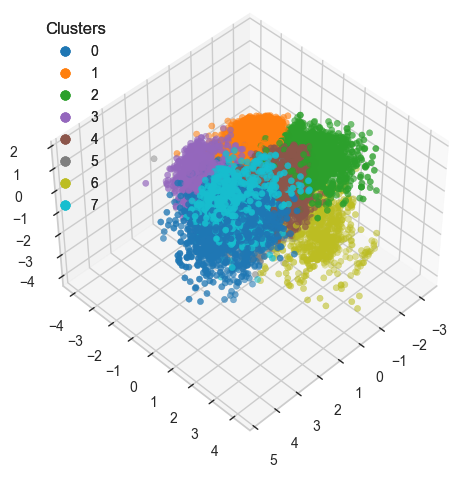

In [126]:
pca = PCA(n_components=3) 
pca_data = pd.DataFrame(pca.fit_transform(X),columns=['PC1','PC2','PC3'])
pca_data['cluster'] = pd.Categorical(kmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(pca_data['PC1'],pca_data['PC2'],pca_data['PC3'],c=pca_data['cluster'].cat.codes, cmap='tab10')
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=45, azim=45)

plt.show()

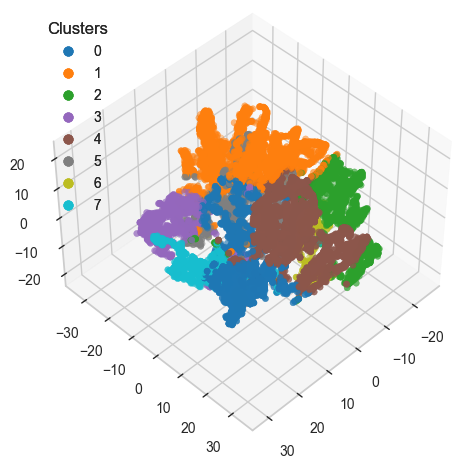

In [127]:
tsne = TSNE(n_components=3, perplexity=30, random_state=42)
tsne_data = pd.DataFrame(tsne.fit_transform(X), columns=['TSNE1', 'TSNE2', 'TSNE3'])
tsne_data['cluster'] = pd.Categorical(kmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    tsne_data['TSNE1'], 
    tsne_data['TSNE2'], 
    tsne_data['TSNE3'], 
    c=tsne_data['cluster'].cat.codes,  
    cmap='tab10'
)
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=45, azim=45)

plt.show()

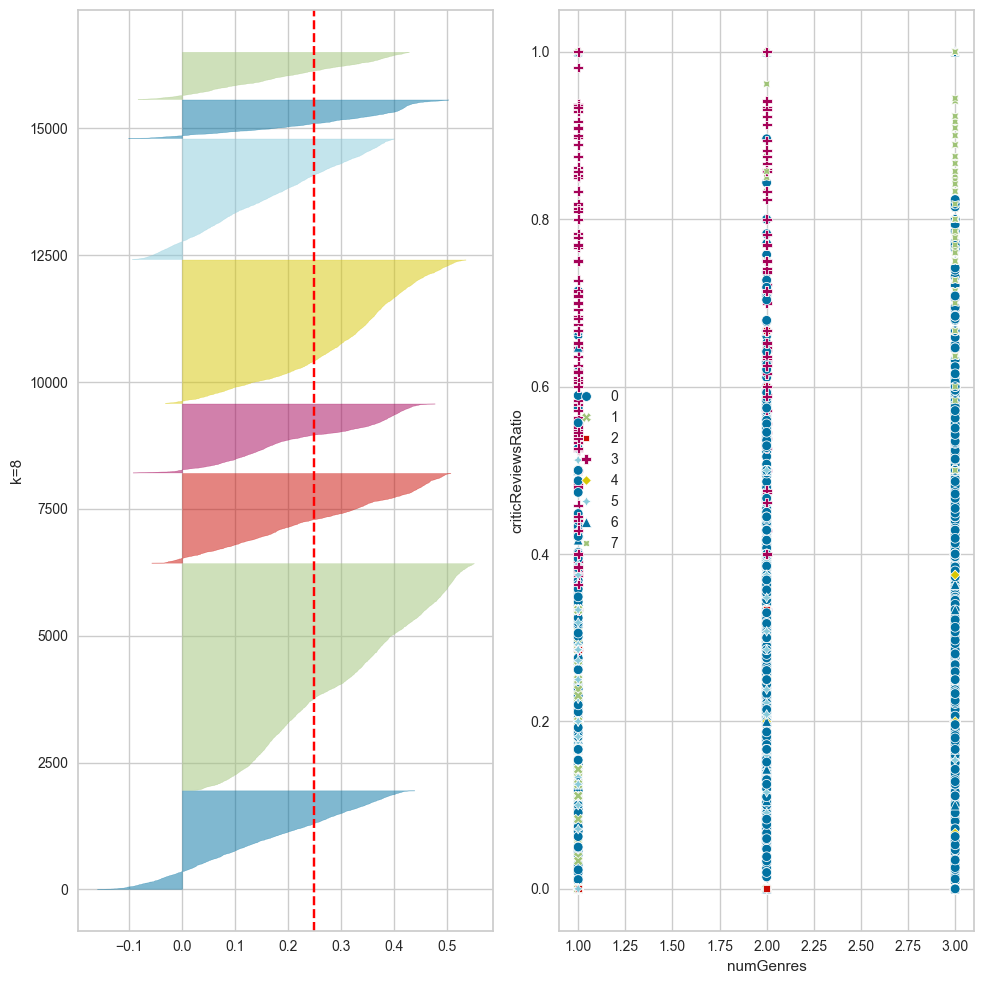

In [128]:
colors=['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
fig, axs = plt.subplots(1, 2, figsize=(10, 10))  # Adjust the size of axs array
visualizer = SilhouetteVisualizer(kmeans, colors=colors, ax=axs[0])
axs[0].set_ylabel("k=" + str(k))
visualizer.fit(X)
sns.scatterplot(data=df, x="numGenres", y="criticReviewsRatio", hue=kmeans.labels_, 
                palette=sns.color_palette(colors), style=kmeans.labels_, ax=axs[1])
plt.tight_layout()
plt.show()

### Qualitative Evaluation
We visualize the distribution of the clusters against interesting known categorical features. The distribution doesn't show pure clusters against any of them, but there are some small insights:
- `titleType`: clusters 0, 2 and 7 show a relevant proportion of shorts. 0 and in particular 7 also have a relevant proportion of tvEpisodes.  Clusters 3 and 5 also show a relevant portion of tvEpisodes, but not of shorts. Clusters 4 and 1 are made up by more than 50% movies; their centroids show the highest values for `logRuntime`.
- `ratingNum`: all clusters follow a normal distribution wrt to the rating.
- `canHaveEpisodes`: most of the True records are in the biggest cluster, Cluster 6. For every cluster, they represent a small proportion (especially for 2 and 5).
- `moreCountriesOfOrigin`: not very informative, True represent a small portion for every cluster, but this is especially true for Cluster 2, which is almost entirely False.
- `awardsAndNominations`: Cluster 2 is characterised by being almost entirely made of records with no awards nor nominations.
- `hasVideos`: Cluster 2 is entirely False, whereas Cluster 3 has the most number of True out of any other cluster, showing a significantly higher proportion.

A clear characterization emerges for Cluster 2: it mostly contains shorts (its centroid has the lowest value for `logRuntime`), and it has very little to no True values for every boolean variable.
Since it's greatly made up of shorts, then movies and tvEpisodes, we can expect the very low value for `canHaveEpisodes`. Its records are produced in just one country, they have mostly no awards nor nominations (we could expect movies and tv series to gain more accolades) and also almost no video content on their page (again, this could reasonably be a feature for blockbusters and mainstream tv series).



In [129]:
df_clusters = df.copy()
df_clusters['Labels'] = kmeans.labels_ #add cluster labels

In [130]:
#categorical_feats = ["originalTitle", "titleType", "countryOfOrigin", "genres",  "ratingNum", "canHaveEpisodes", "hasVideos", "moreCountriesOfOrigin"]
categorical_feats = ["titleType","ratingNum", "canHaveEpisodes", "hasVideos", "moreCountriesOfOrigin", "awardsAndNominations"]

In [131]:
"""
for cat in categorical_feats:
    ct = pd.crosstab(df_clusters[cat], df_clusters['Labels'])
    ct.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(f'Stratified Bar Chart for {cat}')
    plt.xlabel(cat)
    plt.ylabel('Count')
    plt.legend(title='Cluster')
    plt.show()"
"""

'\nfor cat in categorical_feats:\n    ct = pd.crosstab(df_clusters[cat], df_clusters[\'Labels\'])\n    ct.plot(kind=\'bar\', stacked=True, figsize=(10, 6))\n    plt.title(f\'Stratified Bar Chart for {cat}\')\n    plt.xlabel(cat)\n    plt.ylabel(\'Count\')\n    plt.legend(title=\'Cluster\')\n    plt.show()"\n'

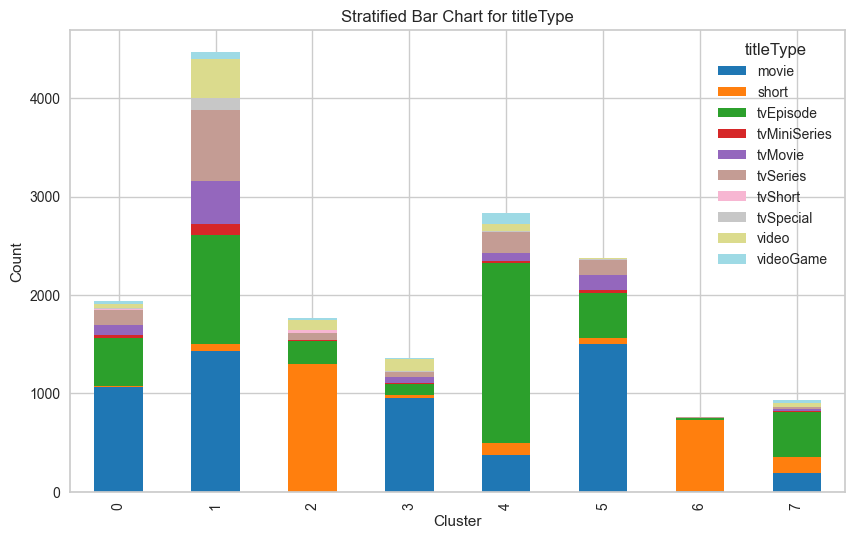

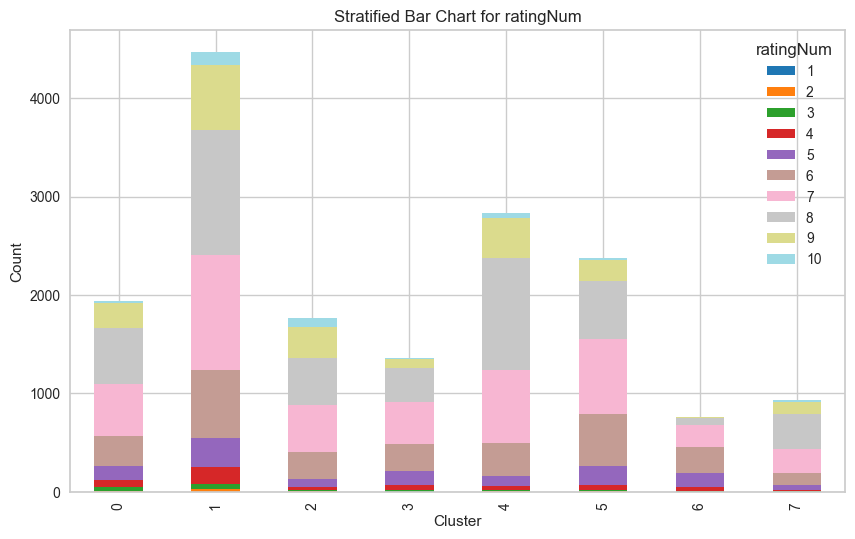

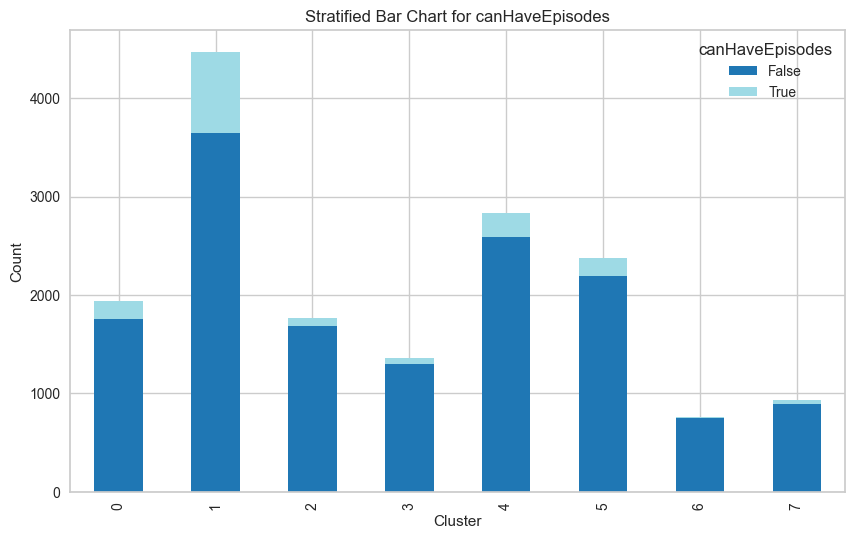

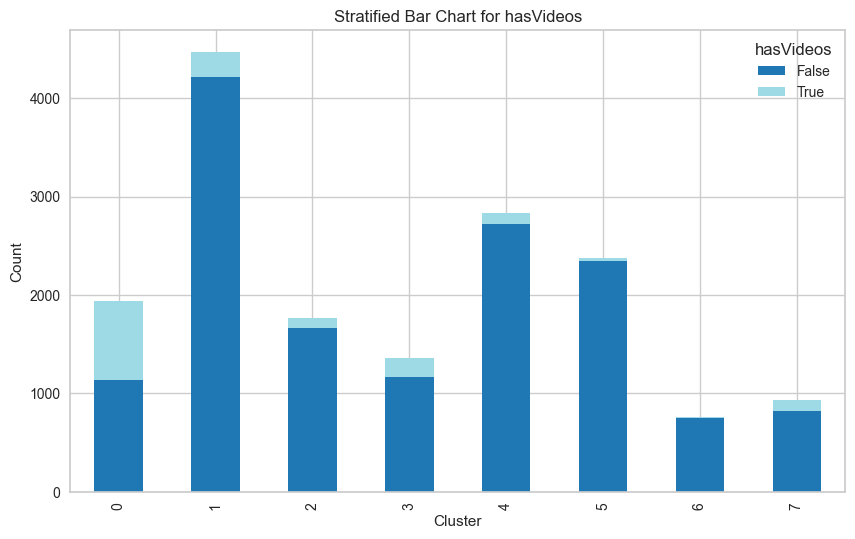

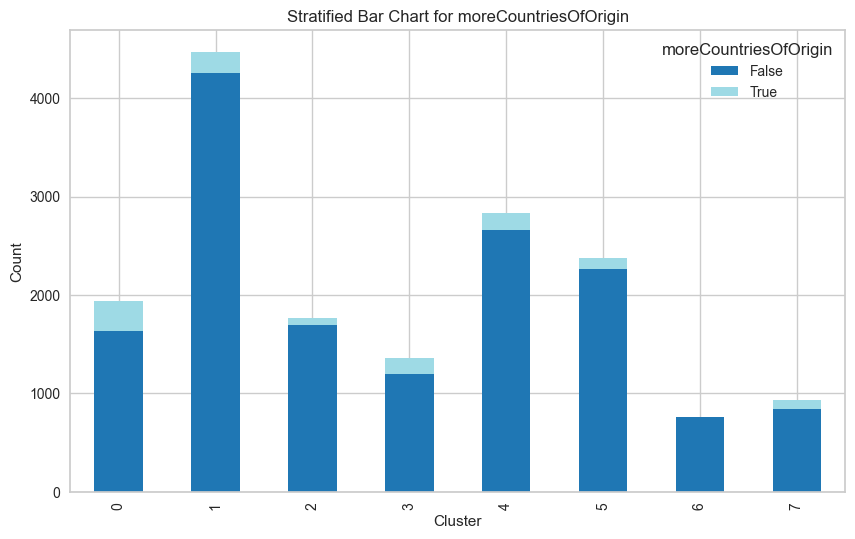

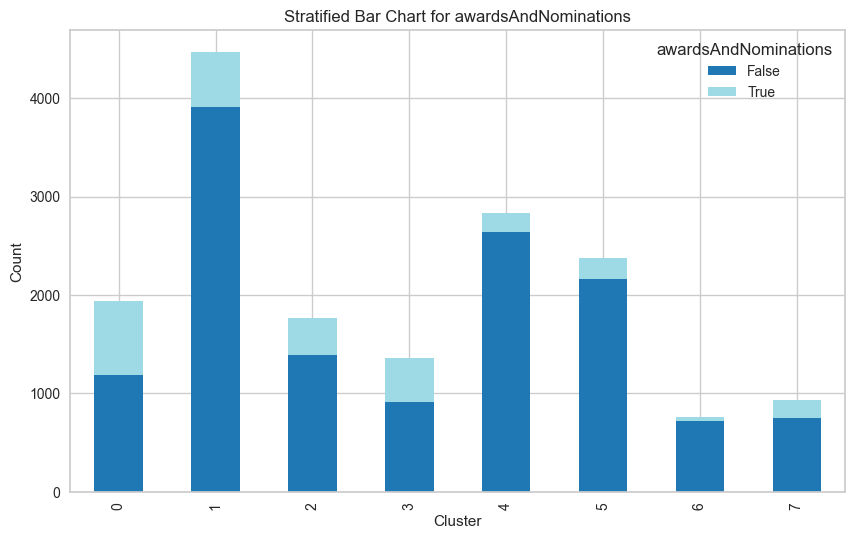

In [132]:
for cat in categorical_feats:
    ct = pd.crosstab(df_clusters['Labels'], df_clusters[cat])
    ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
    plt.title(f'Stratified Bar Chart for {cat}')
    plt.xlabel("Cluster")
    plt.ylabel('Count')
    plt.legend(title=cat)
    plt.show()

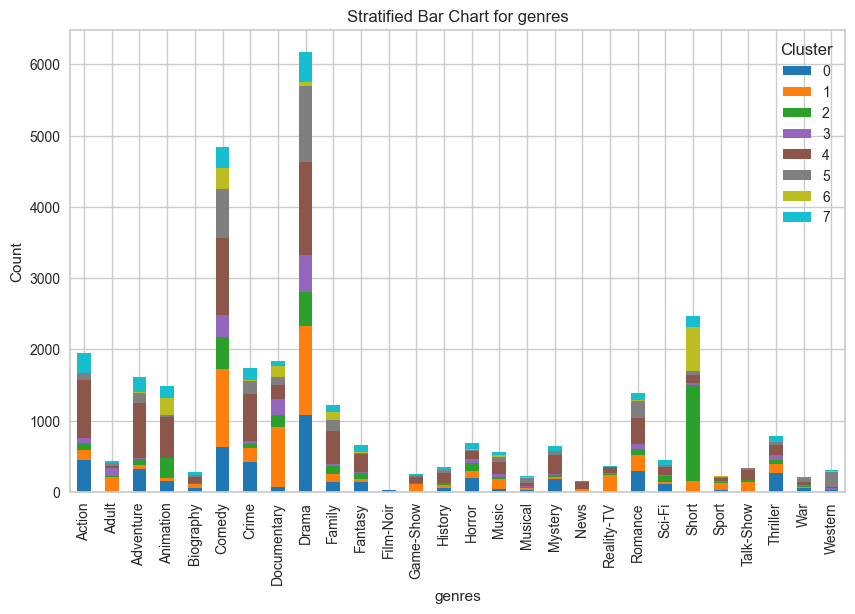

In [133]:
#not very informative
df_clusters_expl = df_clusters.explode('genres')

ct = pd.crosstab(df_clusters_expl["genres"], df_clusters_expl['Labels'])
ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
plt.title(f'Stratified Bar Chart for genres')
plt.xlabel('genres')
plt.ylabel('Count')
plt.legend(title='Cluster')
plt.show()

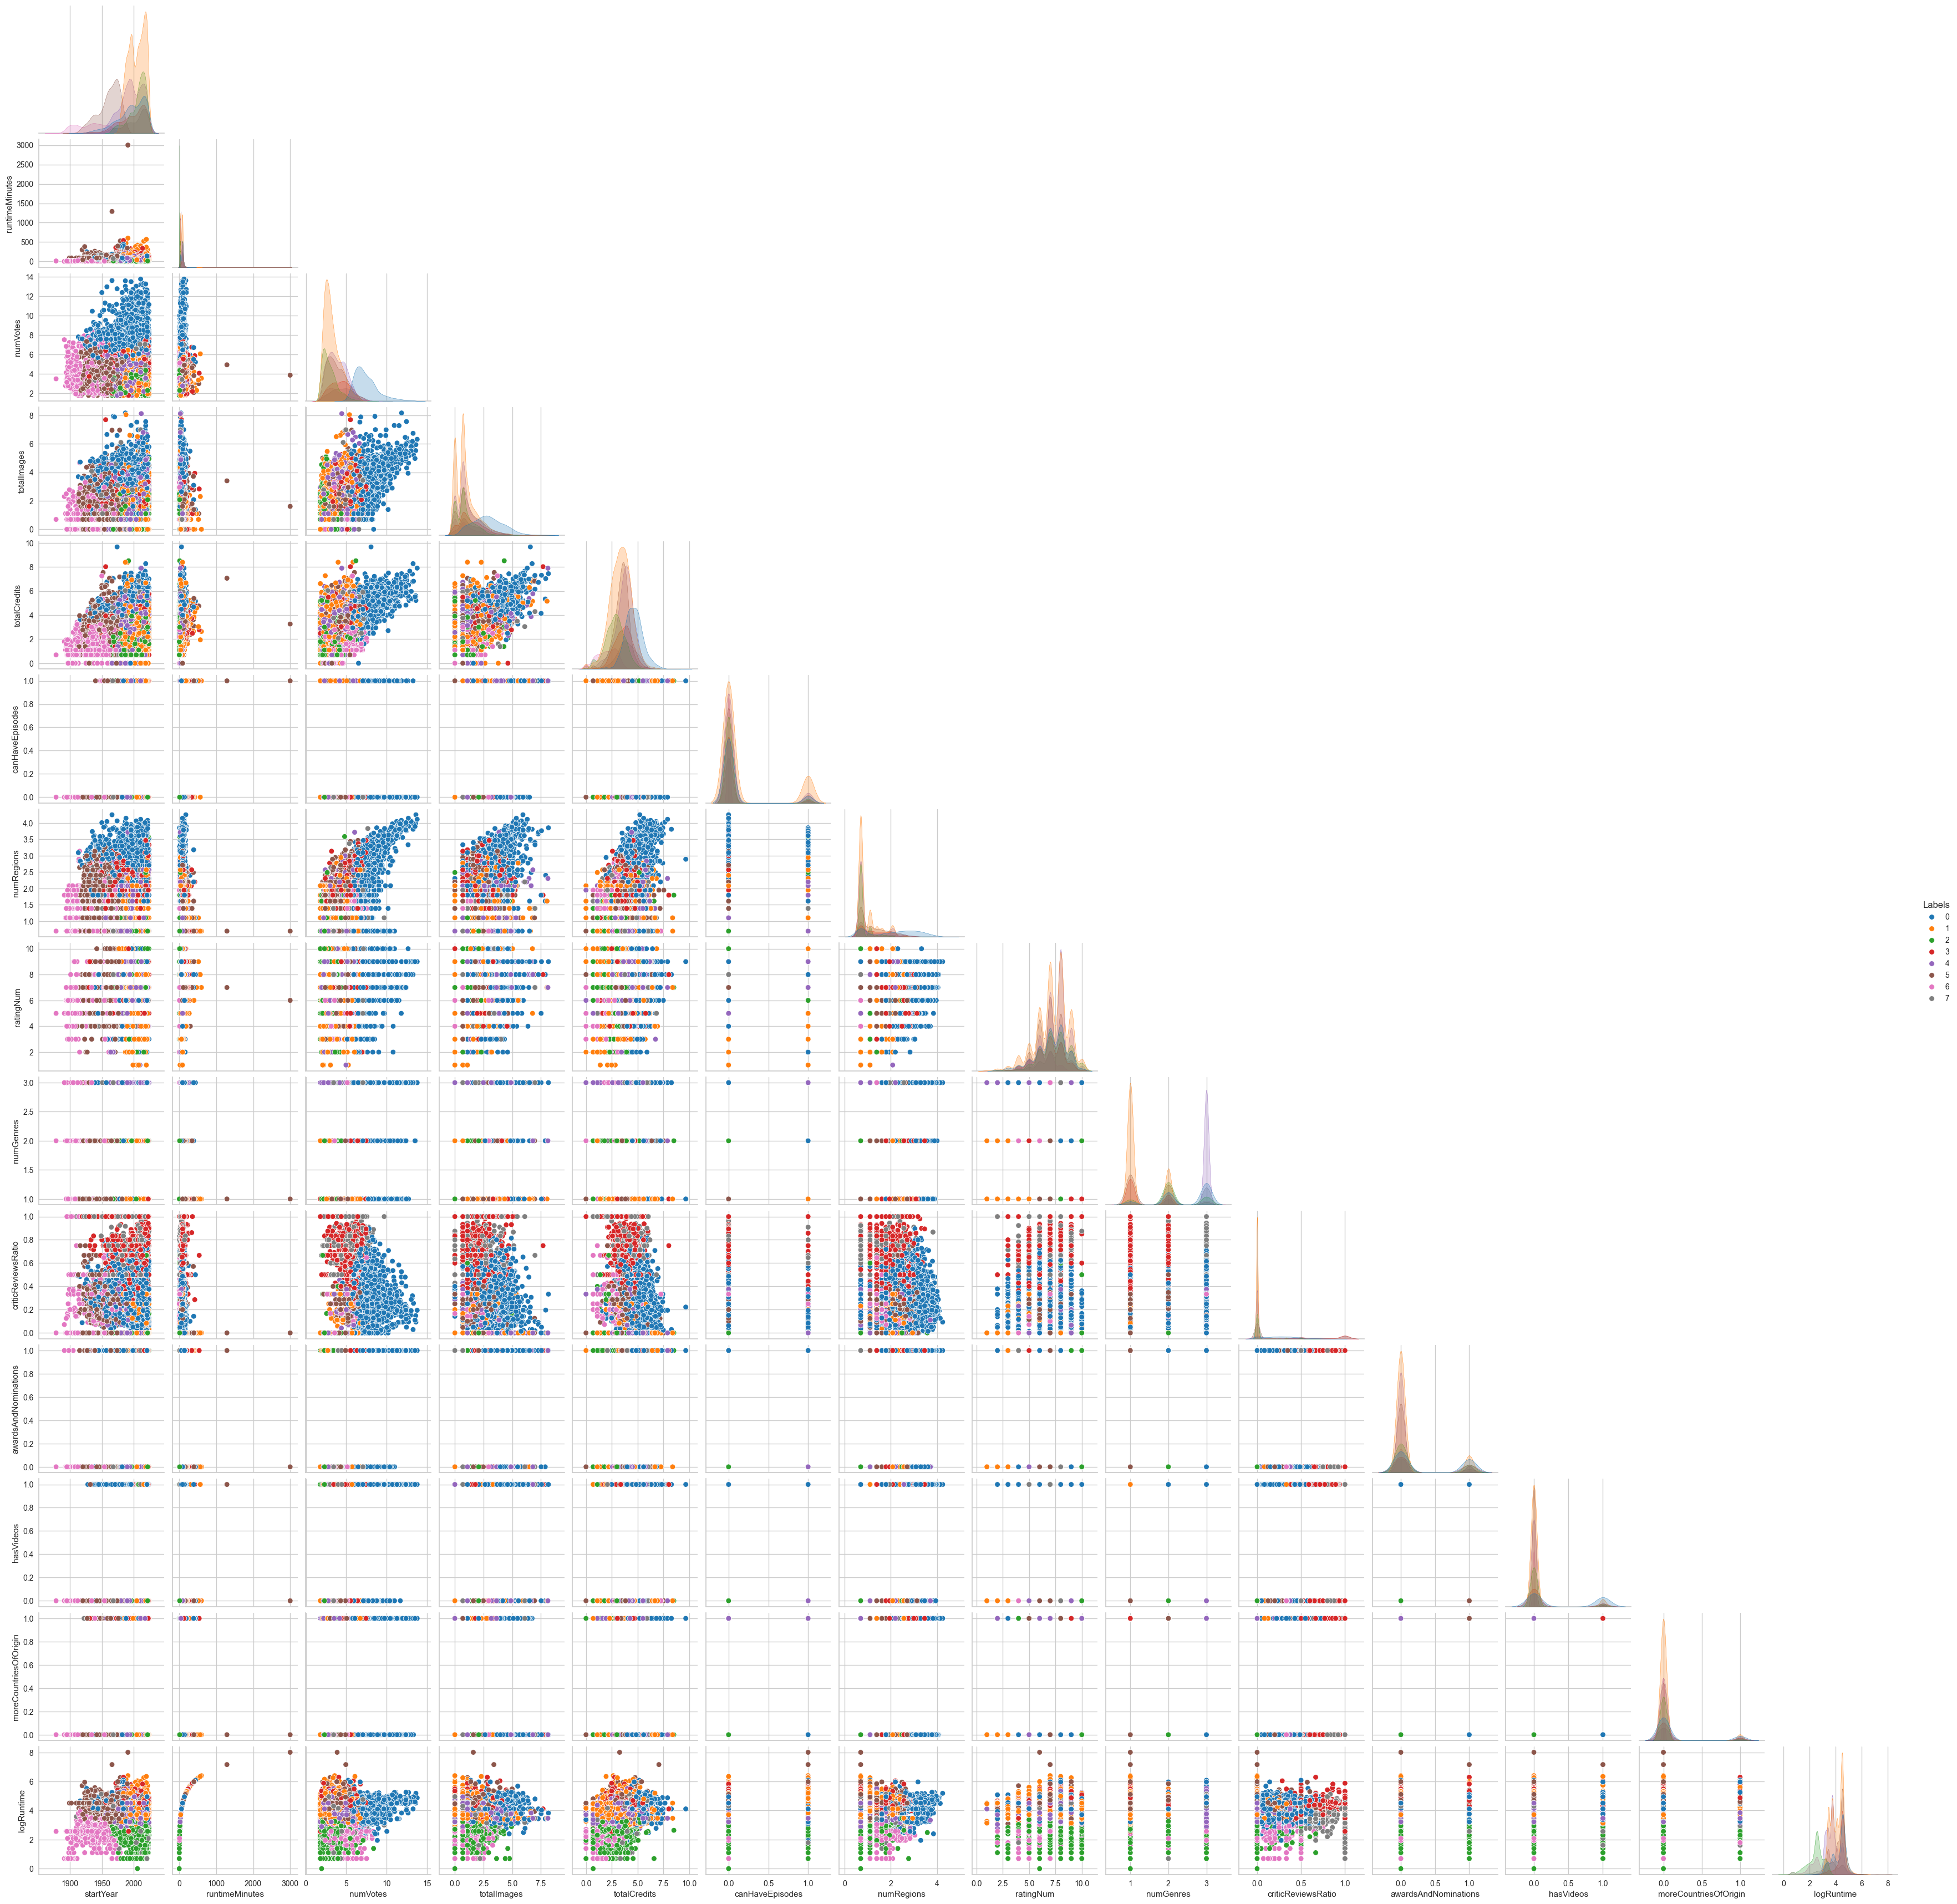

In [134]:
sns.pairplot(df_clusters, hue='Labels', diag_kind='kde', height=2.5, palette='tab10', corner=True)

Let's look at the clusters' composition wrt the numeric variables used by the algorithms.

As hinted by the parallel coordinates plot of the centroid and the PCA visualization, the clusters are mainly separated on the basis of `numGenres`.
- Pure clusters:
    - 0 and 1: 2 genres
    - 3 and 7: 3 genres
    - 4 and 6: 1 genre.
- Non-pure clusters:
    - 2: mostly 2 genres, small proportion of 1 genre.
    - 5: around 60% 3 genres and 40% 2 genres.


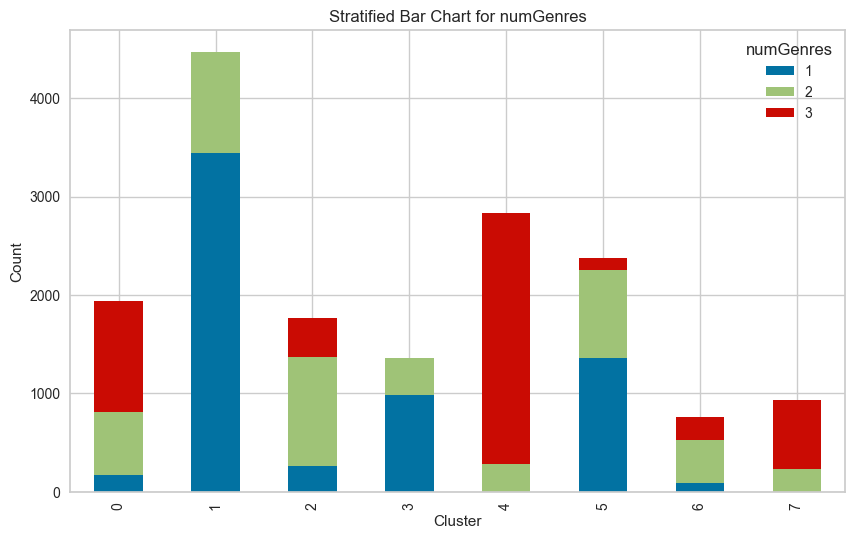

In [135]:
ct = pd.crosstab(df_clusters['Labels'], df_clusters['numGenres'])
ct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title(f'Stratified Bar Chart for numGenres')
plt.xlabel("Cluster")
plt.ylabel('Count')
plt.legend(title="numGenres")
plt.show()

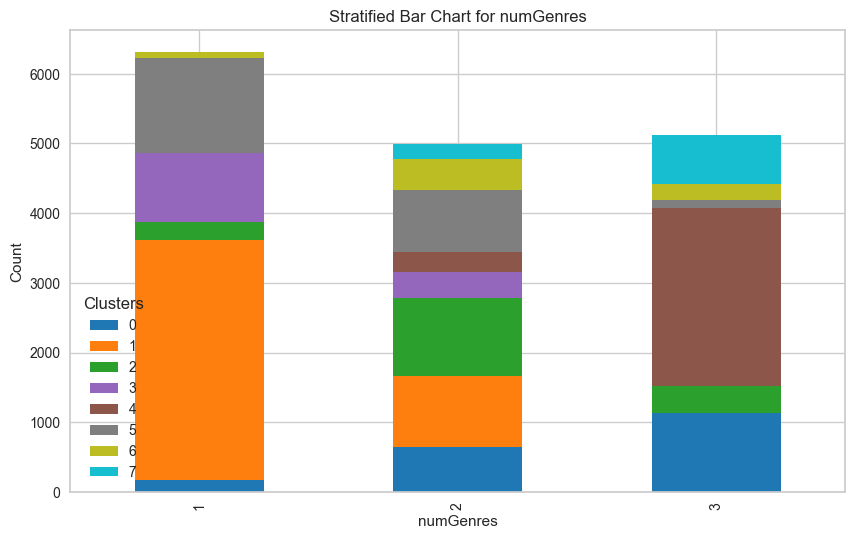

In [136]:
ct = pd.crosstab(df_clusters['numGenres'], df_clusters['Labels'])
ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
plt.title(f'Stratified Bar Chart for numGenres')
plt.xlabel("numGenres")
plt.ylabel('Count')
plt.legend(title="Clusters")
plt.show()

The distribution of the clusters wrt to `criticReviewsRatio` is also interesting.
- Cluster 5 is concentrated at 1.0: the reviews are mostly by critics.
- Cluster 4 also has a high ratio.
- Clusters 1 and 3 show variability, but they are a mostly balanced mix of critic and user reviews. They could represent mainstream content.
- Clusters 0, 2, 6 and 7 are skewed towards 0: their reviews are mostly made by the public. They could represent niche or user driven content (indie or fan-made media).

C:\Users\camim\AppData\Local\Temp\ipykernel_27592\3285363681.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Boxplot of criticReviewsRatio')

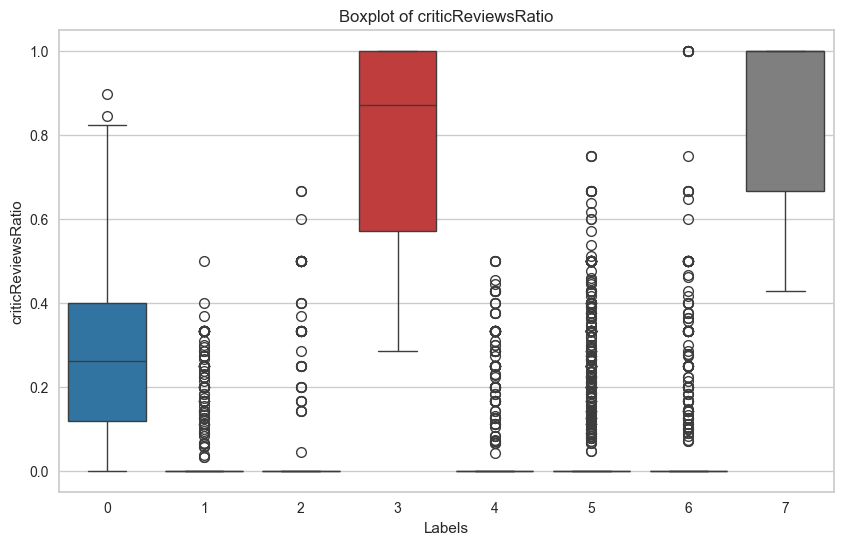

In [137]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clusters, 
    x="Labels", 
    y="criticReviewsRatio", 
    palette="tab10",
    order=sorted(df_clusters['Labels'].unique())
)
plt.title("Boxplot of criticReviewsRatio")


Based on this, we can better visualize the distribution of the clusters wrt the other variables.

- `startYear`: Cluster 2 is separated from the others bc it contains older titles. Clusters 1,6,7 contain titles starting from 1920.
- `logRuntime`: Cluster 2 is characterized by a lower runtime.

In [138]:
# all possible pairings of numerical columns used
pairings = [
    ['startYear', 'numVotes'],
['startYear', 'criticReviewsRatio'],
['startYear', 'logRuntime'],
['numVotes', 'criticReviewsRatio'],
['numVotes', 'logRuntime'],
['criticReviewsRatio', 'logRuntime']

]
df_clusters["Labels"] = df_clusters["Labels"].astype(str)
for pair in pairings:
    fig = px.scatter_3d(df_clusters, x='numGenres', y= pair[0], z=pair[1], color='Labels', color_discrete_sequence=px.colors.qualitative.Set1)
    fig.show()

In [139]:
# Define start_year_counts_by_cluster
start_year_counts_by_cluster = df_clusters.groupby(['Labels', 'startYear']).size().unstack(fill_value=0)

fig = go.Figure()

# Add a line for each cluster
for cluster in start_year_counts_by_cluster.index:
    fig.add_trace(go.Scatter(
        x=start_year_counts_by_cluster.columns,
        y=start_year_counts_by_cluster.loc[cluster],
        mode='lines+markers',
        name=f'Cluster {cluster}'
    ))

# Update layout for better interactivity
fig.update_layout(
    title='Number of Titles by Year for Each Cluster',
    xaxis_title='Year',
    yaxis_title='Number of Titles',
    legend_title='Clusters',
    hovermode='x unified'
)

fig.show()


C:\Users\camim\AppData\Local\Temp\ipykernel_27592\1860860655.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




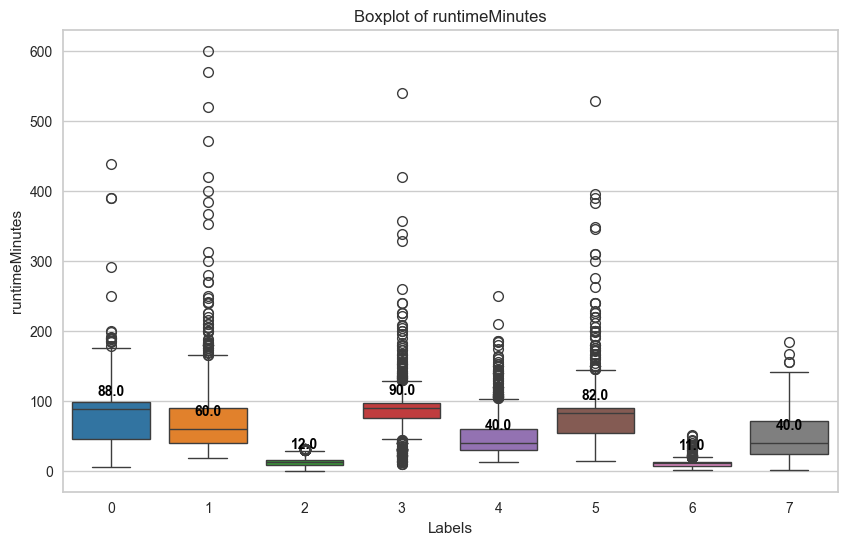

In [140]:
df_clusters_filt = df_clusters[df_clusters['runtimeMinutes'] <= 1000]  # filter outliers for better visualization

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_clusters_filt, 
    x="Labels", 
    y="runtimeMinutes", 
    palette="tab10",
    order=sorted(df_clusters['Labels'].unique())
)

# Calculate and annotate the median for each cluster
medians = df_clusters_filt.groupby("Labels")["runtimeMinutes"].median()
for i, median in enumerate(medians):
    ax.annotate(
        f'{median:.1f}', 
        xy=(i, median), 
        xytext=(0, 10), 
        textcoords='offset points', 
        ha='center', 
        color='black', 
        fontsize=10, 
        fontweight='bold'
    )

plt.title("Boxplot of runtimeMinutes")
plt.show()

C:\Users\camim\AppData\Local\Temp\ipykernel_27592\357536003.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




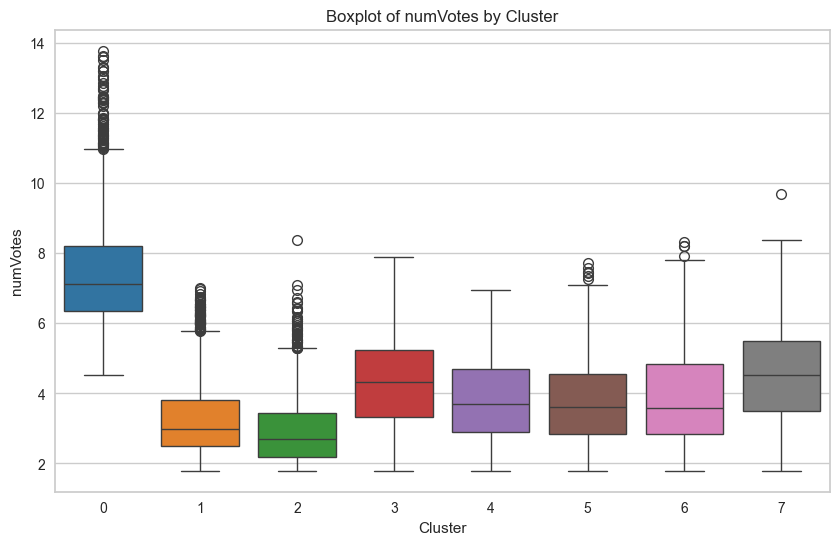

In [141]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clusters, 
    x="Labels", 
    y="numVotes", 
    palette="tab10",
    order=sorted(df_clusters['Labels'].unique())
)
plt.title("Boxplot of numVotes by Cluster")
plt.xlabel("Cluster")
plt.ylabel("numVotes")
plt.show()

### Statistical frameworks for cluster validity:SSE
(too computationally expensive to validate correlation)

Our clustering's SSE is significantly lower than the SSE found in the clustering of 500 randomly generated datasets, which suggests that the clusters found by K-Means in our dataset are meaningful and not a product of chance.

In [142]:
my_sse = kmeans.inertia_
my_sse

30001.022643684704

In [143]:
N = 500
sse_stats = []

for _ in range(N):
    Xi = np.zeros(shape=X.shape)
    
    for cidx in range(Xi.shape[1]):
        col = X[:, cidx]
        min, max, nor = np.min(col), np.max(col), len(col)
        Xi[:, cidx] = np.random.uniform(min, max, (1, nor))
    
    kmeans = KMeans(n_clusters=8, n_init=10, max_iter=100, random_state=94)
    kmeans.fit(Xi)
    sse_stats.append(kmeans.inertia_)
    


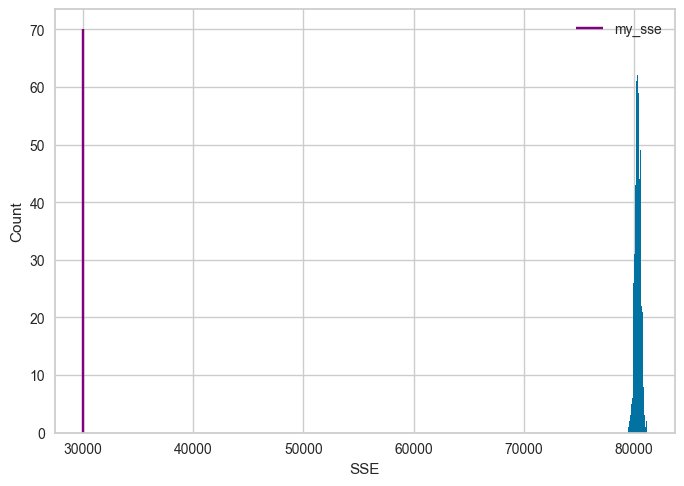

In [144]:
plt.hist(sse_stats, bins='auto')
plt.vlines(x = my_sse, ymin = 0, ymax = 70, colors = 'purple', label = 'my_sse')
plt.xlabel('SSE')
plt.ylabel('Count')
plt.legend()
plt.show()

In [145]:
"""
my_corr = corr
N = 100
corr_stats = []

for _ in range(N):
    Xi = np.zeros(shape=X.shape)
    
    for cidx in range(Xi.shape[1]):
        col = X[:, cidx]
        min, max, nor = np.min(col), np.max(col), len(col)
        Xi[:, cidx] = np.random.uniform(min, max, (1, nor))
    
    kmeans = KMeans(n_clusters=8, n_init=10, max_iter=100, random_state=94)
    kmeans.fit(Xi)

    corr = compute_correlation(Xi, kmeans.labels_)
    corr_stats.append(corr)"
"""

'\nmy_corr = corr\nN = 100\ncorr_stats = []\n\nfor _ in range(N):\n    Xi = np.zeros(shape=X.shape)\n    \n    for cidx in range(Xi.shape[1]):\n        col = X[:, cidx]\n        min, max, nor = np.min(col), np.max(col), len(col)\n        Xi[:, cidx] = np.random.uniform(min, max, (1, nor))\n    \n    kmeans = KMeans(n_clusters=8, n_init=10, max_iter=100, random_state=94)\n    kmeans.fit(Xi)\n\n    corr = compute_correlation(Xi, kmeans.labels_)\n    corr_stats.append(corr)"\n'

In [146]:
"""
plt.hist(corr_stats, bins='auto')
plt.vlines(x = my_corr, ymin = 0, ymax = 60, colors = 'purple', label = 'my_corr')
plt.xlabel('Correlation')
plt.ylabel('Count')
plt.legend()
plt.show()"
"""

'\nplt.hist(corr_stats, bins=\'auto\')\nplt.vlines(x = my_corr, ymin = 0, ymax = 60, colors = \'purple\', label = \'my_corr\')\nplt.xlabel(\'Correlation\')\nplt.ylabel(\'Count\')\nplt.legend()\nplt.show()"\n'

Let's try to see if K-Means extensions can yield better results.

# Bisecting K-means

In [147]:
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df.values)

In [148]:
%%time
sse_list = []
sil_list = []
dist = squareform(pdist(X))

for k in range(2, 51): 
    bkmeans = BisectingKMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
    bkmeans.fit(X)
    sse_list.append(bkmeans.inertia_)
    sil_list.append(silhouette_score(dist, bkmeans.labels_, metric='precomputed'))

CPU times: total: 3min 41s
Wall time: 1min 51s


In [149]:
k_values = list(range(2, 51))  
knee_locator = KneeLocator(k_values, sse_list, curve='convex', direction='decreasing')
print(f"Elbow: {knee_locator.knee}")

Elbow: 14


In [150]:
coeffs = np.array(sil_list)
top_indices = np.argsort(coeffs)[::-1][:15]
top_scores = np.sort(coeffs)[::-1][:15] 

print("Top 15 best k values for silhouette score:")
for k, score in zip(top_indices, top_scores):
    print(f"k = {k+2}, score = {score}") #adjust k value to start from 2

Top 15 best k values for silhouette score:
k = 2, score = 0.25937849228563964
k = 4, score = 0.1619034693519066
k = 3, score = 0.1605270471778315
k = 7, score = 0.15889048686619173
k = 5, score = 0.15431251760045078
k = 6, score = 0.15019404867935915
k = 8, score = 0.12511701039442938
k = 14, score = 0.12272722399633507
k = 13, score = 0.11802480920941971
k = 12, score = 0.11725683549357531
k = 15, score = 0.11342177370007096
k = 9, score = 0.11182812461872442
k = 17, score = 0.10963624772407654
k = 16, score = 0.108471239324441
k = 11, score = 0.10769635247021539


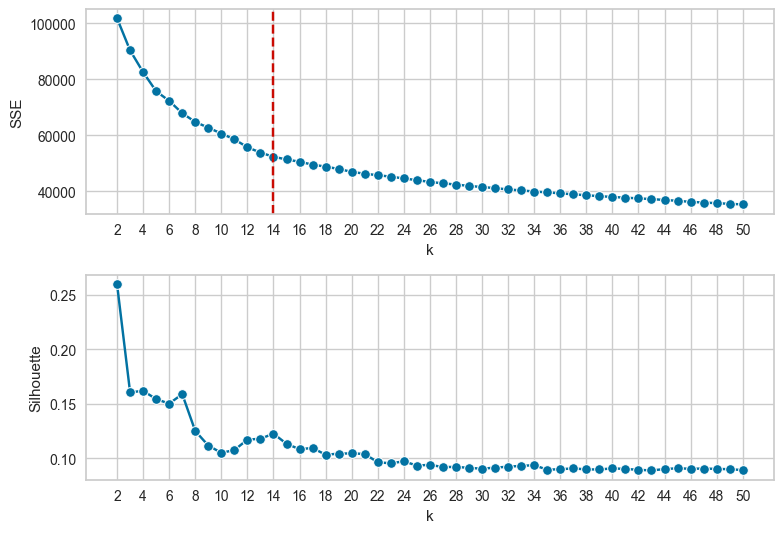

In [151]:
fig, axs = plt.subplots(2) 

sns.lineplot(x=k_values, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')
axs[0].axvline(knee_locator.knee, color='r', linestyle='--')
axs[0].set_xticks(np.arange(2,51,2))

sns.lineplot(x=k_values, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette')
axs[1].set_xticks(np.arange(2,51,2))

plt.tight_layout()

We select k = 6; as the silhouette score is already low, we decide to select its peak.

In [152]:
k = 6

In [153]:
bkmeans = BisectingKMeans(n_clusters=k, n_init=10, max_iter=100, random_state=0)
bkmeans.fit(X)

BisectingKMeans(max_iter=100, n_clusters=6, n_init=10, random_state=0)

In [154]:
labels, counts = np.unique(bkmeans.labels_, return_counts=True)
print("Cluster sizes:")
for label, count in zip(labels,counts):
    print(f"Cluster {label}:\t{count}")

print('\nSSE:', bkmeans.inertia_)
print('Silhouette score:', silhouette_score(X, bkmeans.labels_))

Cluster sizes:
Cluster 0:	3279
Cluster 1:	1397
Cluster 2:	1712
Cluster 3:	3595
Cluster 4:	4184
Cluster 5:	2264

SSE: 72298.9349320725
Silhouette score: 0.12136718114793717


In [155]:
corr = compute_correlation(X, bkmeans.labels_, dist)
print(f"Correlation between the distance matrix and the ideal similarity matrix: {corr}")

Correlation between the distance matrix and the ideal similarity matrix: -0.3730496902298919


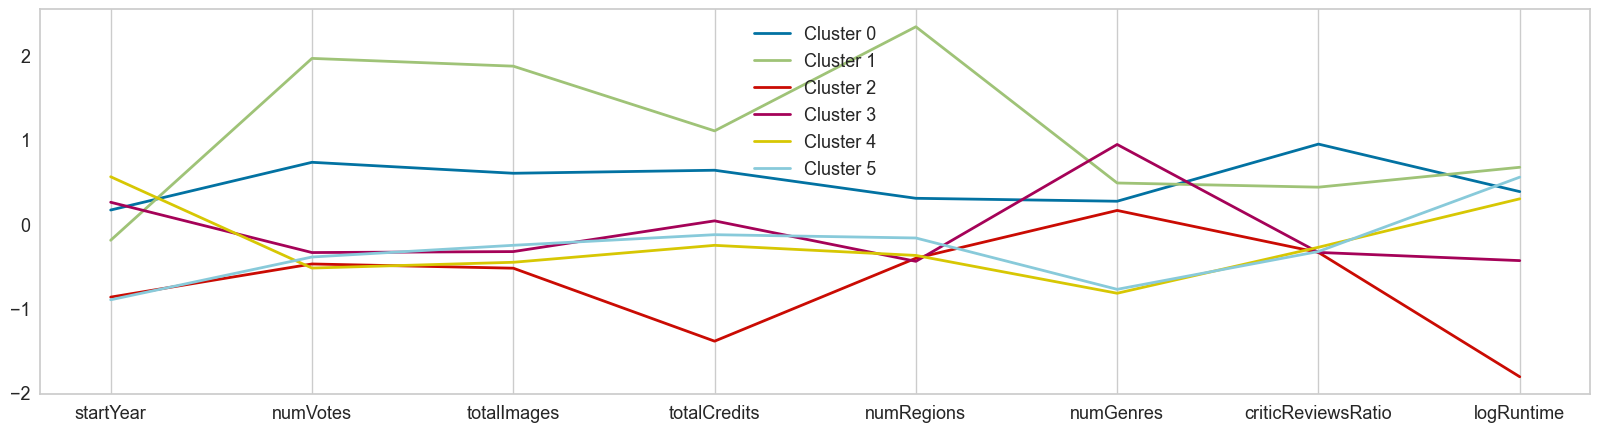

In [156]:
plt.figure(figsize=(20, 5))
centers = bkmeans.cluster_centers_
for i in range(len(centers)):
    plt.plot(range(0, len(numeric_df.columns)), centers[i], label='Cluster %s' % i, linewidth=2)
    
plt.xticks(range(0, len(numeric_df.columns)), numeric_df.columns, fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13, loc='best')
plt.grid(axis='y')

plt.show()

Clusters separate points mostly based on `numGenres` and then `criticReviesRatio`. Cluster 2 is particularly separated from the others based on `numVotes`, `totalImages`, `totalCredits` and `numRegions`, recording higher values than the rest of the clusters, as well as based on `criticReviesRatio`, being the centroid that is most separated from the others.


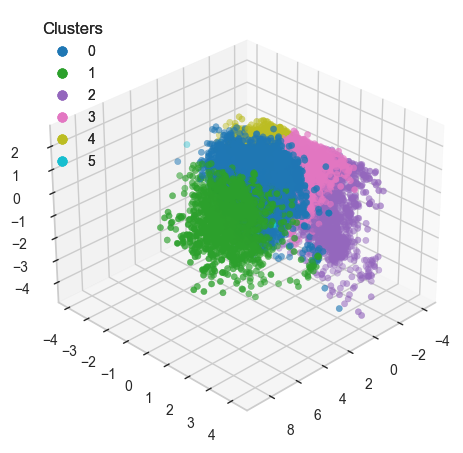

In [157]:
pca = PCA(n_components=3) 
pca_data = pd.DataFrame(pca.fit_transform(X),columns=['PC1','PC2','PC3'])
pca_data['cluster'] = pd.Categorical(bkmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(pca_data['PC1'],pca_data['PC2'],pca_data['PC3'],c=pca_data['cluster'].cat.codes, cmap='tab10')
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=30., azim=45)

plt.show()

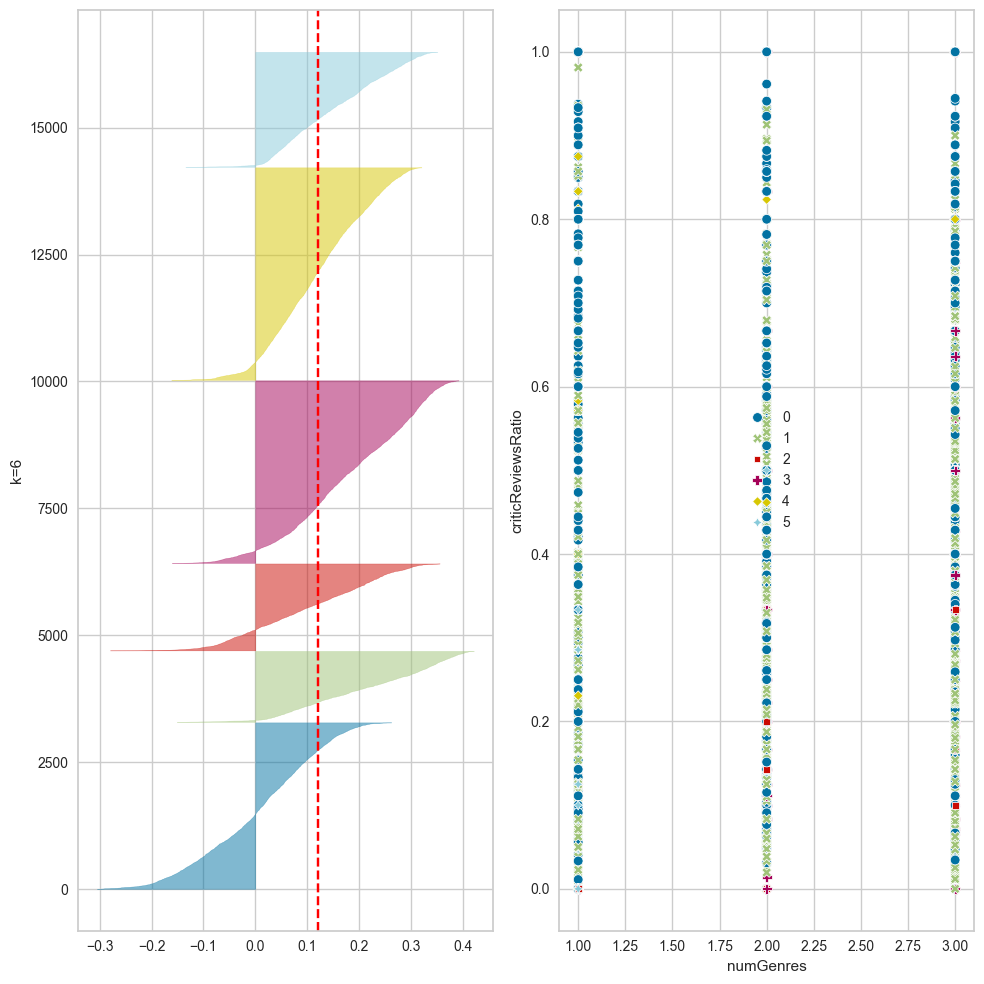

In [158]:
colors=['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
fig, axs = plt.subplots(1, 2, figsize=(10, 10))  # Adjust the size of axs array
visualizer = SilhouetteVisualizer(bkmeans, colors=colors, ax=axs[0])
axs[0].set_ylabel("k=" + str(k))
visualizer.fit(X)
sns.scatterplot(data=df, x="numGenres", y="criticReviewsRatio", hue=bkmeans.labels_, 
                palette=sns.color_palette(colors), style=bkmeans.labels_, ax=axs[1])
plt.tight_layout()
plt.show()

## Bisecting K-means with selected features
Let's do the same selection of features we did for K-Means.

In [159]:
scaler = StandardScaler()
X = scaler.fit_transform(selected_numeric_df.values)

In [160]:
%%time
sse_list = []
sil_list = []
dist = squareform(pdist(X))

for k in range(2, 51): 
    bkmeans = BisectingKMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
    bkmeans.fit(X)
    sse_list.append(bkmeans.inertia_)
    sil_list.append(silhouette_score(dist, bkmeans.labels_, metric='precomputed'))

CPU times: total: 3min 13s
Wall time: 1min 44s


In [161]:
k_values = list(range(2, 51))  
knee_locator = KneeLocator(k_values, sse_list, curve='convex', direction='decreasing')
print(f"Elbow: {knee_locator.knee}")

Elbow: 10


In [162]:
coeffs = np.array(sil_list)
top_indices = np.argsort(coeffs)[::-1][:15]
top_scores = np.sort(coeffs)[::-1][:15] 

print("Top 15 best k values for silhouette score:")
for k, score in zip(top_indices, top_scores):
    print(f"k = {k+2}, score = {score}") #adjust k value to start from 2

Top 15 best k values for silhouette score:
k = 2, score = 0.27509952830100026
k = 5, score = 0.25147936489456935
k = 4, score = 0.2453568999948119
k = 3, score = 0.22209708620492444
k = 9, score = 0.22100602488400137
k = 8, score = 0.2167221894929742
k = 6, score = 0.2155160544730044
k = 7, score = 0.2151117909864188
k = 40, score = 0.21010795101399282
k = 39, score = 0.2092410905948885
k = 42, score = 0.20889287107691806
k = 41, score = 0.20863139715229673
k = 38, score = 0.20808124358949331
k = 37, score = 0.20704875915237955
k = 36, score = 0.20603560202062768


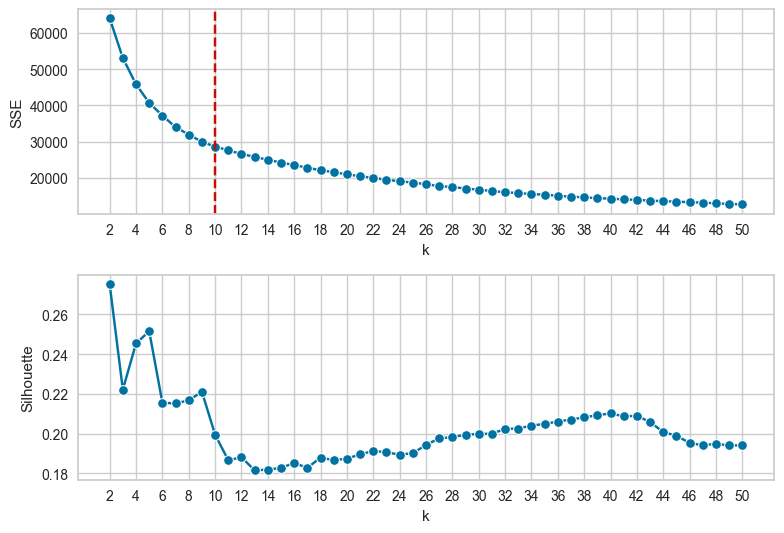

In [163]:
fig, axs = plt.subplots(2) 

sns.lineplot(x=k_values, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')
axs[0].axvline(knee_locator.knee, color='r', linestyle='--')
axs[0].set_xticks(np.arange(2,51,2))

sns.lineplot(x=k_values, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette')
axs[1].set_xticks(np.arange(2,51,2))

plt.tight_layout()

Once again, selecting fewer features lead to an improvement. We select k = 6.

In [168]:
k = 9 #k = 6

In [169]:
bkmeans = BisectingKMeans(n_clusters=k, n_init=10, max_iter=100, random_state=0)
bkmeans.fit(X)

BisectingKMeans(max_iter=100, n_clusters=9, n_init=10, random_state=0)

In [170]:
labels, counts = np.unique(bkmeans.labels_, return_counts=True)
print("Cluster sizes:")
for label, count in zip(labels,counts):
    print(f"Cluster {label}:\t{count}")

print('\nSSE:', bkmeans.inertia_)
print('Silhouette score:', silhouette_score(X, bkmeans.labels_))

Cluster sizes:
Cluster 0:	773
Cluster 1:	1359
Cluster 2:	1560
Cluster 3:	1061
Cluster 4:	2204
Cluster 5:	3909
Cluster 6:	1330
Cluster 7:	3237
Cluster 8:	998

SSE: 29969.949014793136
Silhouette score: 0.2208732755326578


The SEE and Silhouette scores are better than before, but slightly worse than regular K means with k = 8. This is the best value for correlation.

In [171]:
corr = compute_correlation(X, bkmeans.labels_, dist)
print(f"Correlation between the distance matrix and the ideal similarity matrix: {corr}")

Correlation between the distance matrix and the ideal similarity matrix: -0.4851355471858872


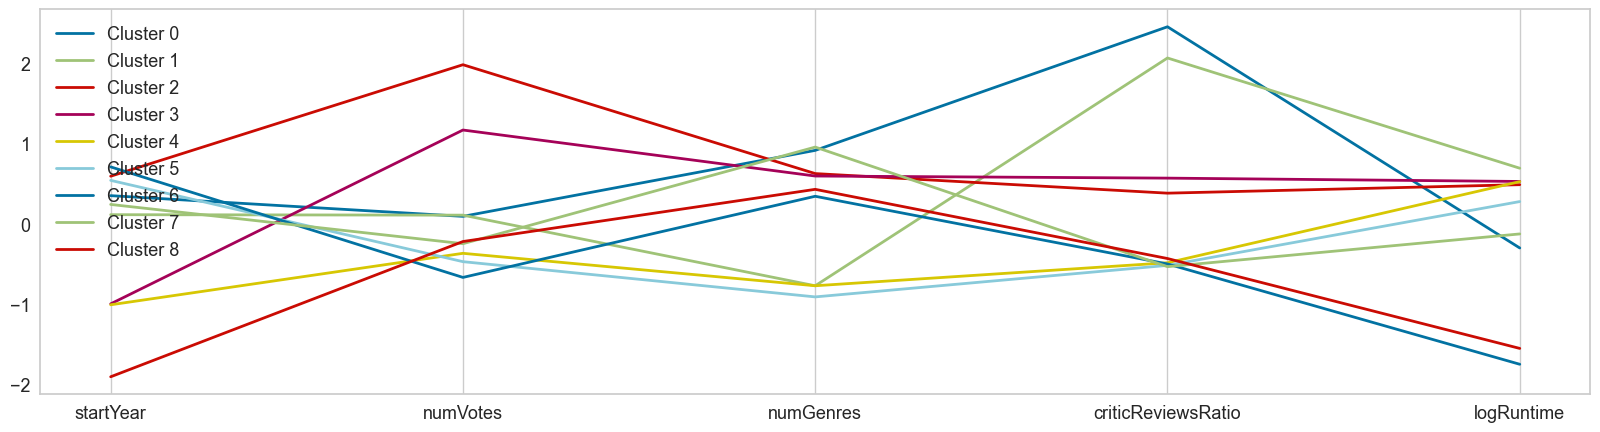

In [172]:
plt.figure(figsize=(20, 5))
centers = bkmeans.cluster_centers_
for i in range(len(centers)):
    plt.plot(range(0, len(selected_numeric_df.columns)), centers[i], label='Cluster %s' % i, linewidth=2)
    
plt.xticks(range(0, len(selected_numeric_df.columns)), selected_numeric_df.columns, fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13, loc='best')
plt.grid(axis='y')

plt.show()

Similarly as before, clusters separate points mostly based on `numGenres`and `criticReviesRatio`. Cluster 3 is particularly separated from the others based on `numVotes`.


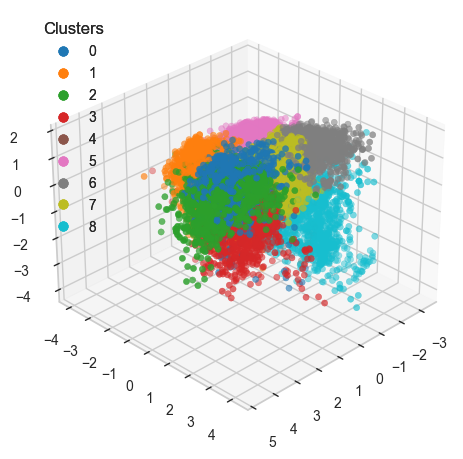

In [173]:
pca = PCA(n_components=3) 
pca_data = pd.DataFrame(pca.fit_transform(X),columns=['PC1','PC2','PC3'])
pca_data['cluster'] = pd.Categorical(bkmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(pca_data['PC1'],pca_data['PC2'],pca_data['PC3'],c=pca_data['cluster'].cat.codes, cmap='tab10')
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=30., azim=45)

plt.show()

C:\Users\camim\AppData\Local\Temp\ipykernel_27592\1960751410.py:6: UserWarning:


The palette list has fewer values (6) than needed (9) and will cycle, which may produce an uninterpretable plot.



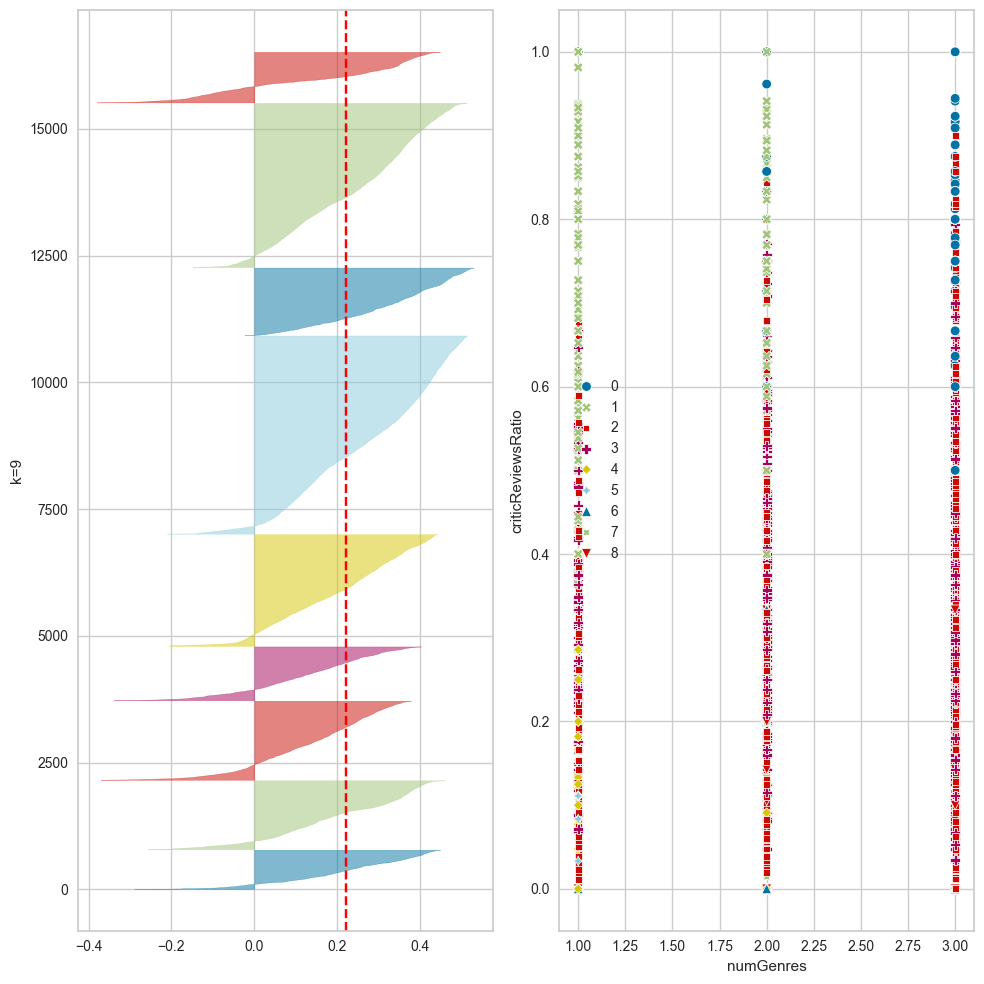

In [174]:
colors=['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
fig, axs = plt.subplots(1, 2, figsize=(10, 10))  # Adjust the size of axs array
visualizer = SilhouetteVisualizer(bkmeans, colors=colors, ax=axs[0])
axs[0].set_ylabel("k=" + str(k))
visualizer.fit(X)
sns.scatterplot(data=df, x="numGenres", y="criticReviewsRatio", hue=bkmeans.labels_, 
                palette=sns.color_palette(colors), style=bkmeans.labels_, ax=axs[1])
plt.tight_layout()
plt.show()

# X-Means

In [175]:
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df.values)

In [176]:
import warnings
np.warnings = warnings

xm = xmeans.xmeans(X, random_state=0)
xm.process()

In [177]:
def clusters_to_labels(clusters):
    labels = np.empty(shape=(len(np.concatenate(clusters))), dtype=int)
    for i in range(len(clusters)):
        for idx in clusters[i]:
            labels[idx] = i
    return labels

In [178]:
clusters = xm.get_clusters()
labels = clusters_to_labels(clusters)

C:\Users\camim\AppData\Local\Temp\ipykernel_27592\3338670677.py:8: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



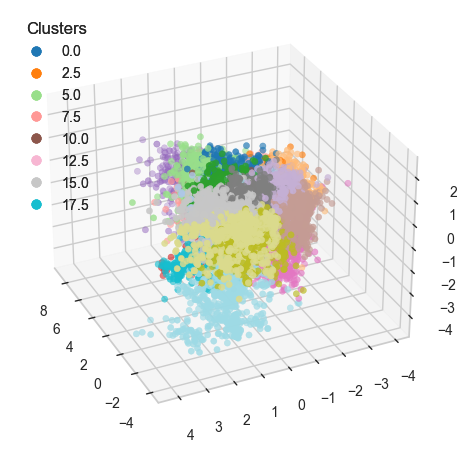

In [179]:
pca = PCA(n_components=3)  # Initialize a PCA model with 2 components
pca_data = pd.DataFrame(pca.fit_transform(X),columns=['PC1','PC2','PC3'])
pca_data['cluster'] = pd.Categorical(labels)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

cmap = plt.cm.get_cmap('tab20', 20)
scatter = ax.scatter(pca_data['PC1'],pca_data['PC2'],pca_data['PC3'],c=pca_data['cluster'], cmap = cmap)
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=30., azim=155)

plt.show()

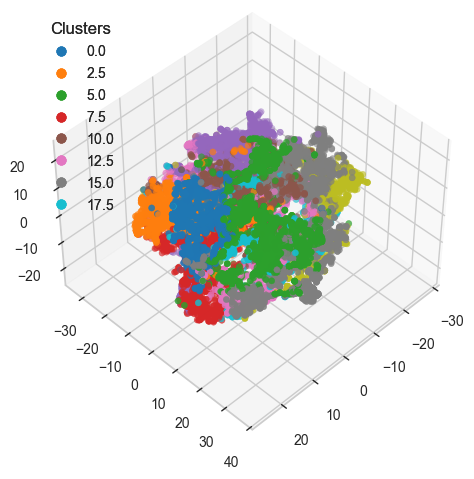

In [180]:
tsne = TSNE(n_components=3, perplexity=30, random_state=42)
tsne_data = pd.DataFrame(tsne.fit_transform(X), columns=['TSNE1', 'TSNE2', 'TSNE3'])
tsne_data['cluster'] = pd.Categorical(labels)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    tsne_data['TSNE1'], 
    tsne_data['TSNE2'], 
    tsne_data['TSNE3'], 
    c=tsne_data['cluster'].cat.codes,  
    cmap='tab10'
)
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=45, azim=45)

plt.show()

In [181]:
print("Number of clusters:", len(clusters))
labels_xm, counts = np.unique(labels, return_counts=True)
for l, c in zip(labels_xm,counts):
    print('Cluster ', l, ': ', c)
print('Silhouette: ', silhouette_score(X, labels))
print('SSE: ', xm.get_total_wce())

Number of clusters: 20
Cluster  0 :  639
Cluster  1 :  303
Cluster  2 :  796
Cluster  3 :  861
Cluster  4 :  1151
Cluster  5 :  584
Cluster  6 :  616
Cluster  7 :  707
Cluster  8 :  353
Cluster  9 :  1393
Cluster  10 :  653
Cluster  11 :  1691
Cluster  12 :  1333
Cluster  13 :  624
Cluster  14 :  1550
Cluster  15 :  868
Cluster  16 :  508
Cluster  17 :  740
Cluster  18 :  598
Cluster  19 :  463
Silhouette:  0.1485935091561405
SSE:  42642.11408778644


In [182]:
corr = compute_correlation(X, labels)
print(f"Correlation between the distance matrix and the ideal similarity matrix: {corr}")

Correlation between the distance matrix and the ideal similarity matrix: -0.3274729057485429


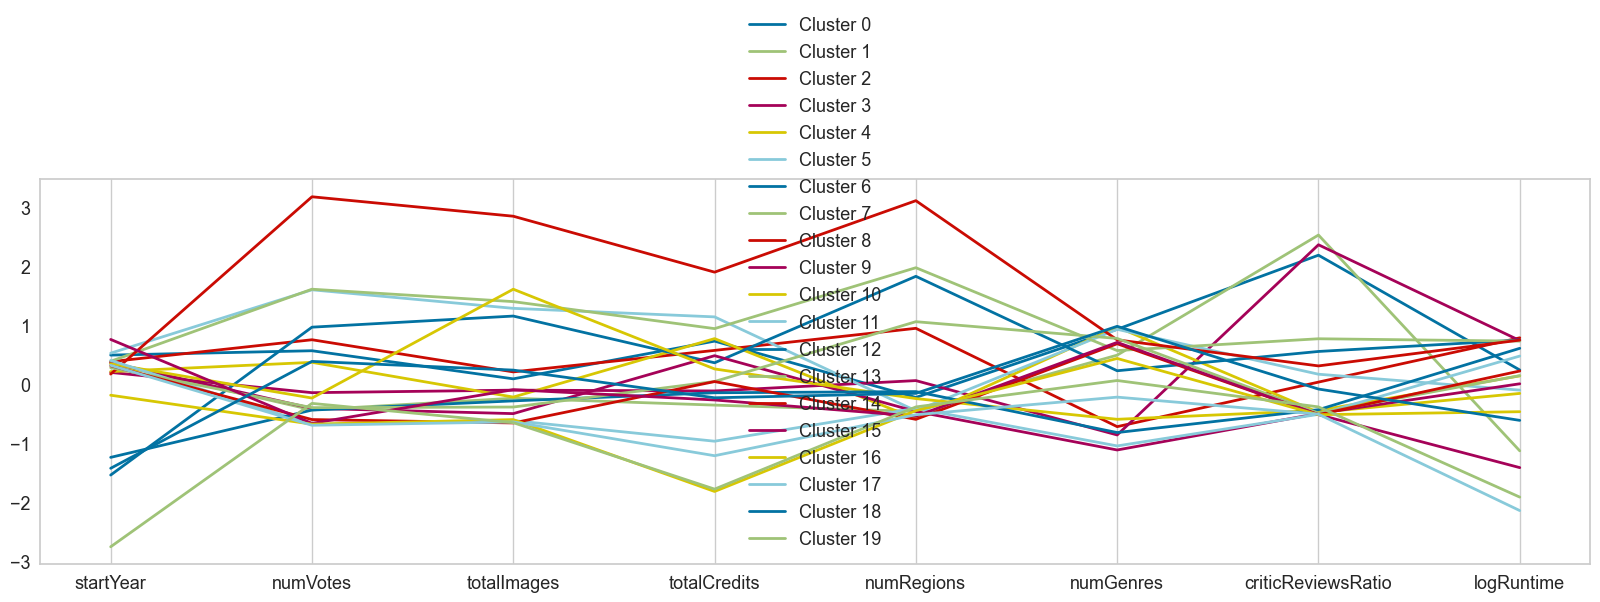

In [183]:
plt.figure(figsize=(20, 5))
centers = xm.get_centers()
for i in range(len(centers)):
    plt.plot(range(0, len(numeric_df.columns)), centers[i], label='Cluster %s' % i, linewidth=2)
    
plt.xticks(range(0, len(numeric_df.columns)), numeric_df.columns, fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13, loc='best')
plt.grid(axis='y')

plt.show()

## Selected features

In [184]:
scaler = StandardScaler()
X = scaler.fit_transform(selected_numeric_df.values)

In [185]:
xm = xmeans.xmeans(X, random_state=0)
xm.process()

In [186]:
def clusters_to_labels(clusters):
    labels = np.empty(shape=(len(np.concatenate(clusters))), dtype=int)
    for i in range(len(clusters)):
        for idx in clusters[i]:
            labels[idx] = i
    return labels

In [187]:
clusters = xm.get_clusters()
labels = clusters_to_labels(clusters)

C:\Users\camim\AppData\Local\Temp\ipykernel_27592\3338670677.py:8: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



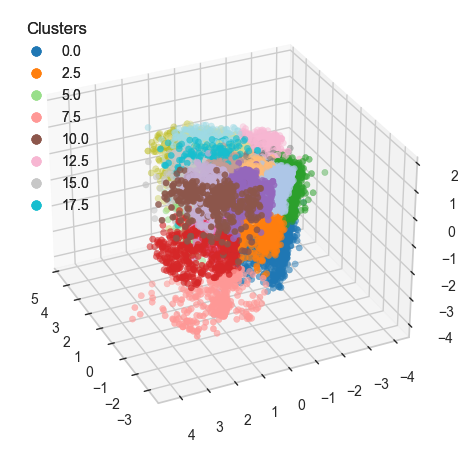

In [188]:
pca = PCA(n_components=3)  # Initialize a PCA model with 2 components
pca_data = pd.DataFrame(pca.fit_transform(X),columns=['PC1','PC2','PC3'])
pca_data['cluster'] = pd.Categorical(labels)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

cmap = plt.cm.get_cmap('tab20', 20)
scatter = ax.scatter(pca_data['PC1'],pca_data['PC2'],pca_data['PC3'],c=pca_data['cluster'], cmap = cmap)
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=30., azim=155)

plt.show()

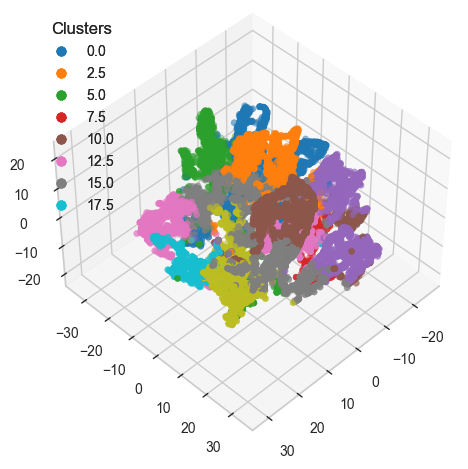

In [189]:
tsne = TSNE(n_components=3, perplexity=30, random_state=42)
tsne_data = pd.DataFrame(tsne.fit_transform(X), columns=['TSNE1', 'TSNE2', 'TSNE3'])
tsne_data['cluster'] = pd.Categorical(labels)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    tsne_data['TSNE1'], 
    tsne_data['TSNE2'], 
    tsne_data['TSNE3'], 
    c=tsne_data['cluster'].cat.codes,  
    cmap='tab10'
)
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=45, azim=45)

plt.show()

In [190]:
print("Number of clusters:", len(clusters))
labels_xm, counts = np.unique(labels, return_counts=True)
for l, c in zip(labels_xm,counts):
    print('Cluster ', l, ': ', c)
print('Silhouette: ', silhouette_score(X, labels))
print('SSE: ', xm.get_total_wce())

Number of clusters: 20
Cluster  0 :  1083
Cluster  1 :  1369
Cluster  2 :  910
Cluster  3 :  1412
Cluster  4 :  1756
Cluster  5 :  676
Cluster  6 :  408
Cluster  7 :  353
Cluster  8 :  947
Cluster  9 :  807
Cluster  10 :  391
Cluster  11 :  1009
Cluster  12 :  676
Cluster  13 :  947
Cluster  14 :  851
Cluster  15 :  877
Cluster  16 :  462
Cluster  17 :  725
Cluster  18 :  289
Cluster  19 :  483
Silhouette:  0.2230306220061947
SSE:  18920.557347065238


In [191]:
corr = compute_correlation(X, labels)
print(f"Correlation between the distance matrix and the ideal similarity matrix: {corr}")

Correlation between the distance matrix and the ideal similarity matrix: -0.3772186893934807


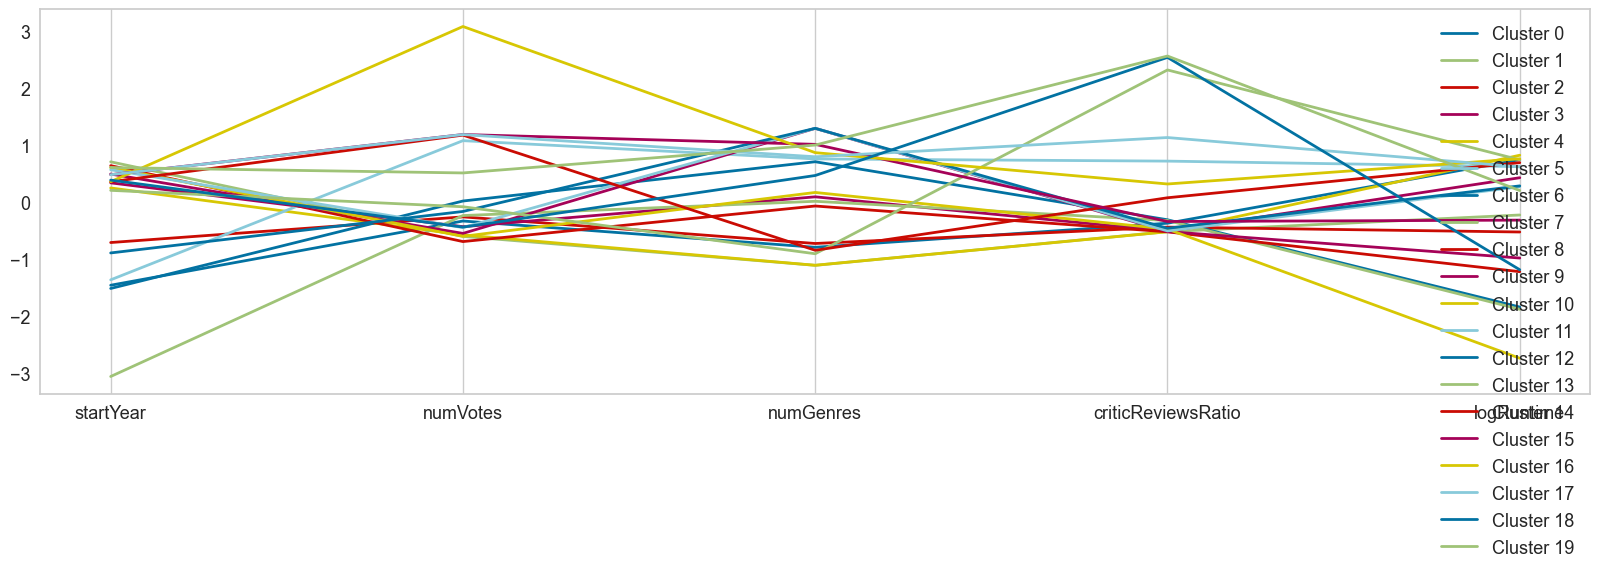

In [192]:
plt.figure(figsize=(20, 5))
centers = xm.get_centers()
for i in range(len(centers)):
    plt.plot(range(0, len(selected_numeric_df.columns)), centers[i], label='Cluster %s' % i, linewidth=2)
    
plt.xticks(range(0, len(selected_numeric_df.columns)), selected_numeric_df.columns, fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13, loc='best')
plt.grid(axis='y')

plt.show()

Two clusters are quite separated wrt to `startYear`, they probably contain the oldest titles. Another couple of centroids have significantly lower values for `logRuntime`, they probably contain short media formats (shorts, tvShorts, tvEpisode). 

Clusters seem to be quite separated wrt to `startYear`, homogenously separated wrt to `numGenres`(there seems to be an uniform number of records for each of the 3 values), and especially separated wrt to `criticReviesRatio`.

The silhouette is worse than by using K-Means with k=8 or Bisecting K-Means with k = 6, but there's an improvement in SSE.

## Qualitative Evaluation

In [193]:
df_clusters['Labels'] = labels # overwrite w/ xmeans labels

Categorical Vars
- Cluster 7: among the smallest but pure/almost pure wrt to many feats → `titleType` (shorts), all boolean feats (False). Cluster 3, which is mostly shorts, behaves similarly.
- Cluster 17: mostly True for `hasVideo` and `awardsAndNominations`.
- `titleType`
    - interesting distribution of shorts for 7 (almost pure), 5 (biggest n. overall), 3
    - tvShorts: overall few, but are mostly distrbuted in Cluster 2 (25% of tvShorts are here) and 5 (22.5%). Seems to indicate that tvShrots are 'merged' with the two most frequent forms of short media content (shorts and tvEpisodes)

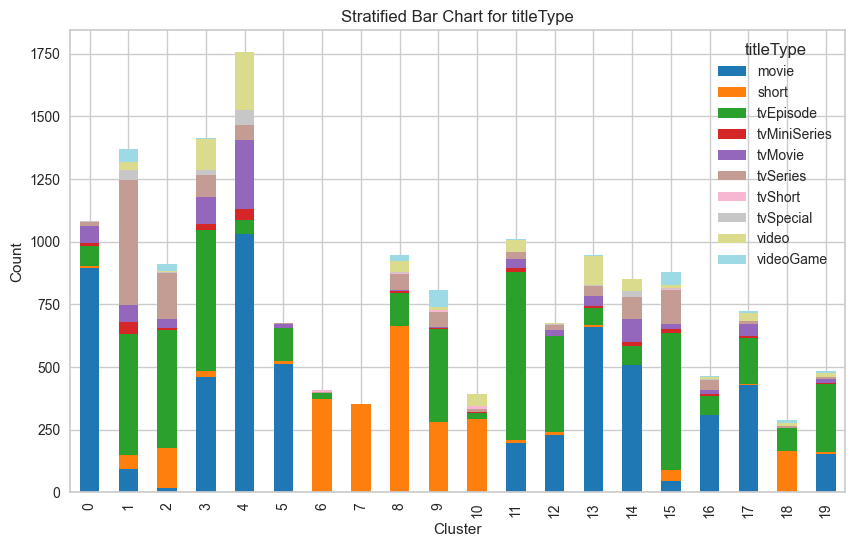

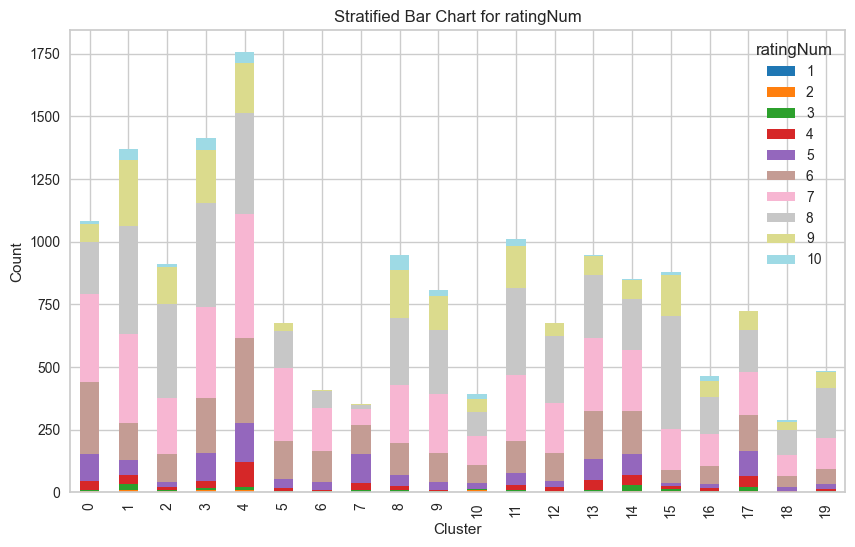

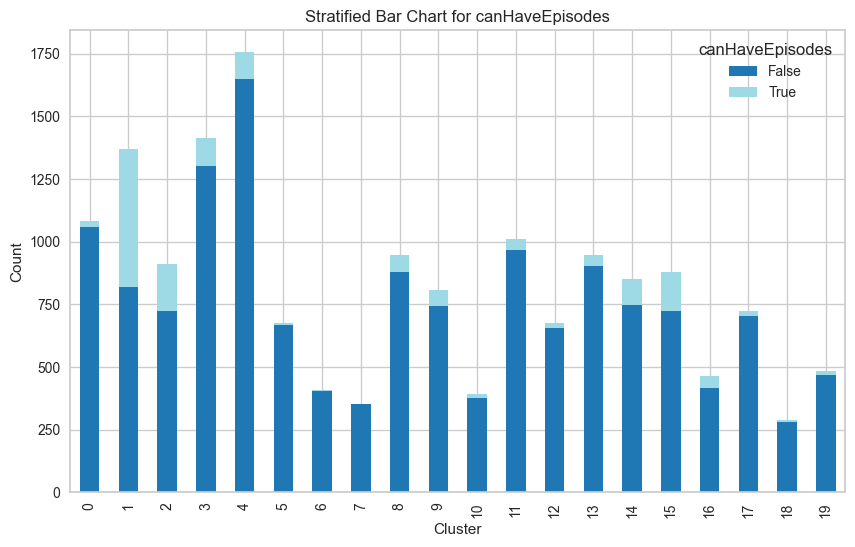

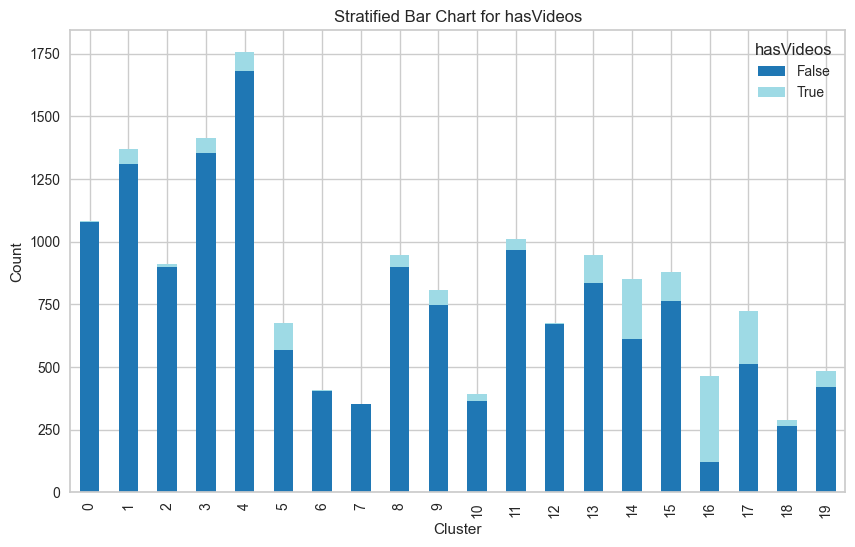

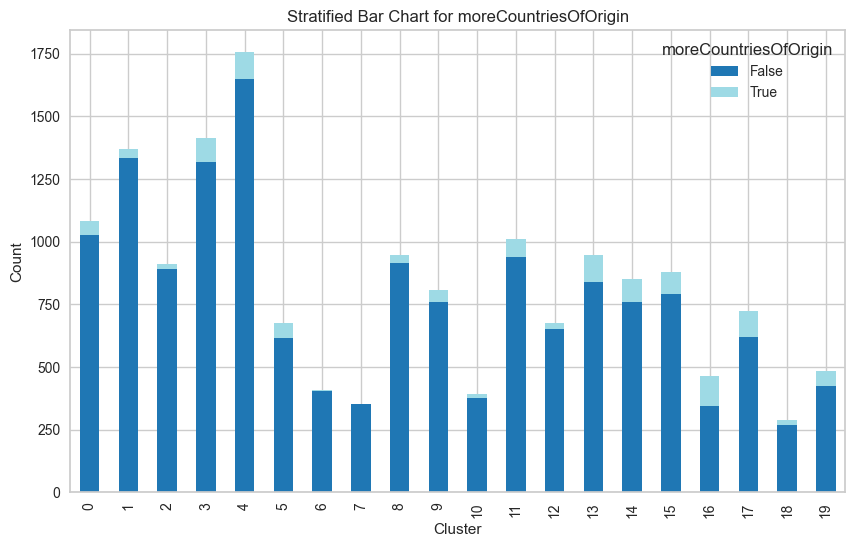

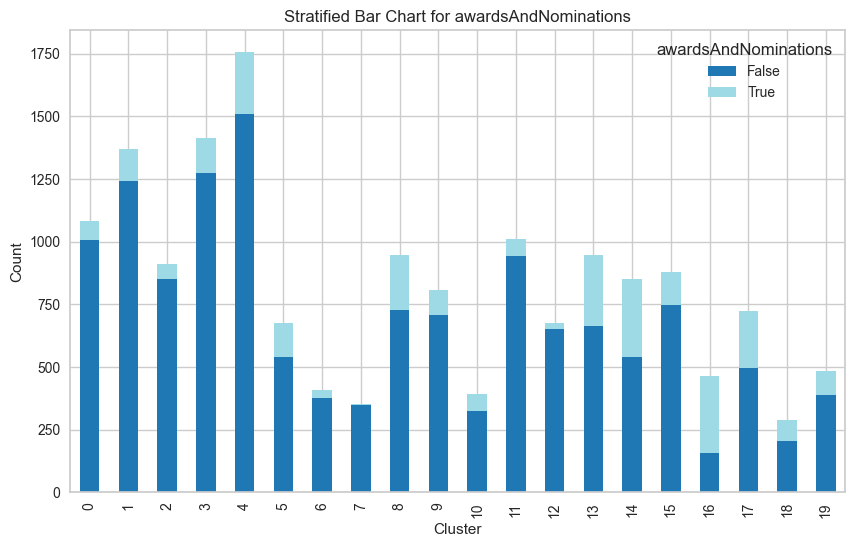

In [194]:
for cat in categorical_feats:
    ct = pd.crosstab(df_clusters['Labels'], df_clusters[cat])
    ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
    plt.title(f'Stratified Bar Chart for {cat}')
    plt.xlabel("Cluster")
    plt.ylabel('Count')
    plt.legend(title=cat)
    plt.show()

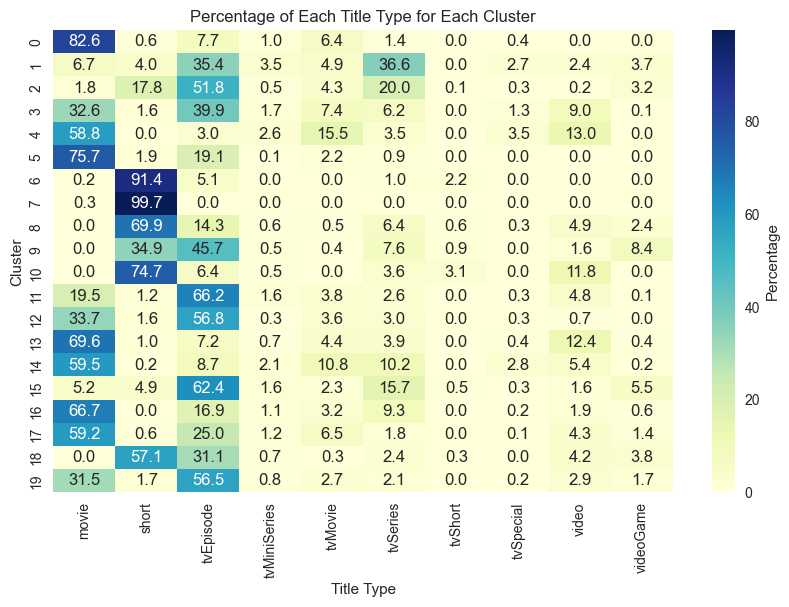

In [195]:
# Calculate the percentage of each title type for each cluster
title_type_percentage = pd.crosstab(df_clusters['Labels'], df_clusters['titleType'], normalize='index') * 100

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(title_type_percentage, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage'})
plt.title("Percentage of Each Title Type for Each Cluster")
plt.xlabel("Title Type")
plt.ylabel("Cluster")
plt.show()

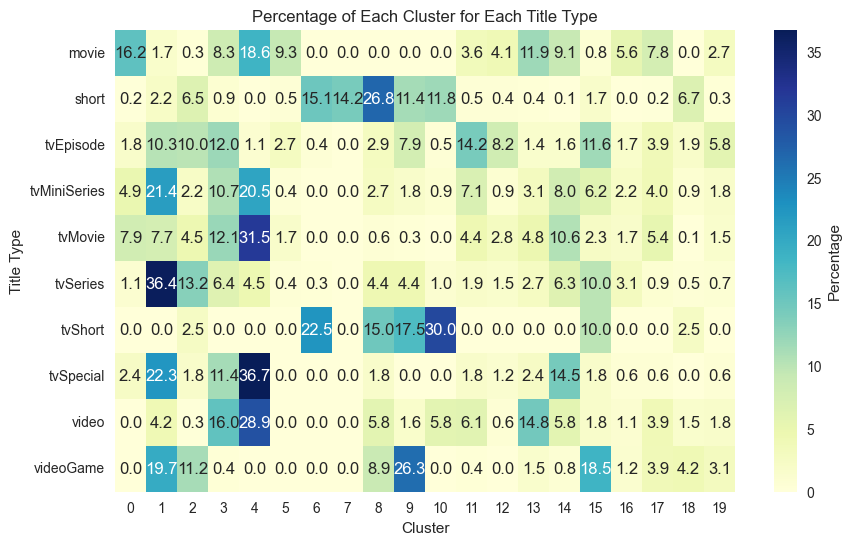

In [196]:
# Calculate the percentage of each title type for each cluster
title_type_percentage = pd.crosstab(df_clusters['titleType'], df_clusters['Labels'], normalize='index') * 100

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(title_type_percentage, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage'})
plt.title("Percentage of Each Cluster for Each Title Type")
plt.ylabel("Title Type")
plt.xlabel("Cluster")
plt.show()

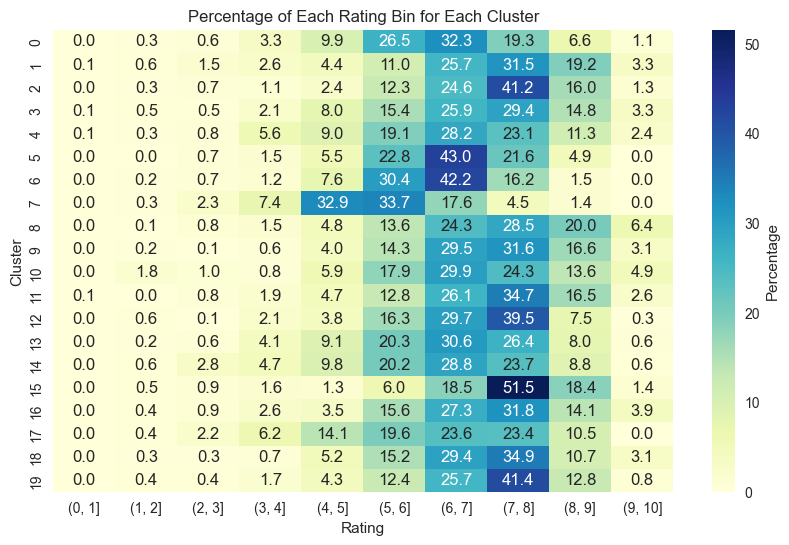

In [197]:
# Calculate the percentage of each title type for each cluster
title_type_percentage = pd.crosstab(df_clusters['Labels'], df_clusters['rating'], normalize='index') * 100

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(title_type_percentage, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage'})
plt.title("Percentage of Each Rating Bin for Each Cluster")
plt.xlabel("Rating")
plt.ylabel("Cluster")
plt.show()

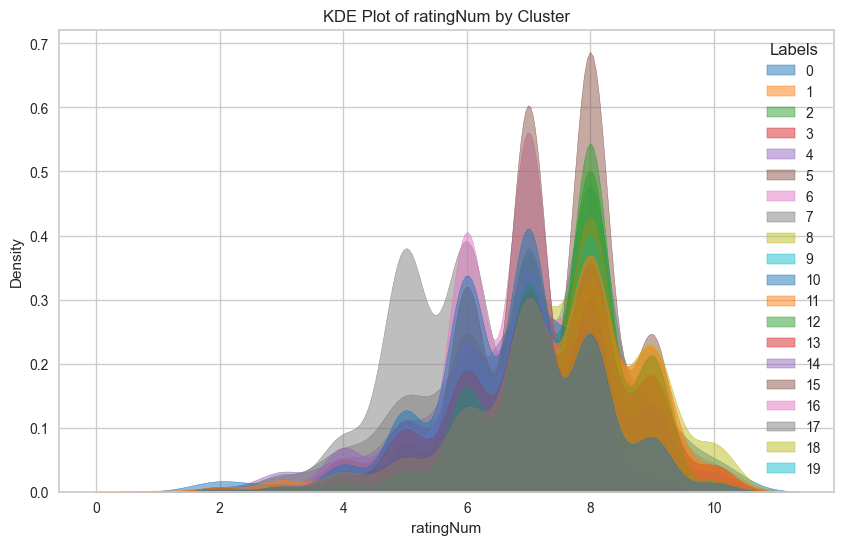

In [198]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_clusters, x="ratingNum", hue="Labels", fill=True, common_norm=False, palette="tab10", alpha=0.5)
plt.title("KDE Plot of ratingNum by Cluster")
plt.xlabel("ratingNum")
plt.ylabel("Density")
plt.show()